# 10×10 铰接水弹性模型：验证、位移、参数对比与内力计算

本 notebook 的结构按照今天的研究任务组织：

1. 先验证 Yoon 单铰接、双铰接算例，确认铰接接口和响应数据可复用。
2. 再实现 10×10 铰接模型的水弹性位移计算或读取。
3. 先比较全铰接、高刚度和均匀弹性三类连接方案，证明连接刚度优化的必要性。
4. 总结斜入射水动力数据，并对比 pitch 铰接刚度 `0 / 1e8 / 1e9 / 1e10` 的中轴线响应。
5. 最后绘制连接件内力、浮体模块内力，其中内力重点输出剪切力和弯矩。

所有核心算法仍从 `src/offshore_energy_sim` 调用；notebook 只负责实验组织、注释说明、结果检查和图表输出。

In [1]:
# ===== 0. 基础环境与路径设置 =====
# 这一节只做路径、依赖和输出目录准备，不进行任何数值计算。

# 启用 Python 未来版本的类型注解行为，避免部分类型提示在运行时被立即求值。
from __future__ import annotations

# Path 用于管理仓库、数据和结果文件路径。
from pathlib import Path

# csv 用于把连接件内力和模块内力结果写成可复查的表格。
import csv

# os 用于读取环境变量，例如外部数据根目录 RODM_DM_FEM_ROOT。
import os

# sys 用于把本仓库的 src 目录加入 Python 搜索路径。
import sys

# matplotlib 用于绘制位移云图、中心线响应、剪切力和弯矩图。
import matplotlib.pyplot as plt

# numpy 是本项目矩阵、向量和复数响应处理的基础库。
import numpy as np

# NOTEBOOK_CWD 记录当前运行目录；从 Jupyter 打开时通常是 notebooks，也可能是仓库根目录。
NOTEBOOK_CWD = Path.cwd()

# REPO_ROOT 统一定位到项目根目录，保证 notebook 从根目录或 notebooks 目录运行都可用。
REPO_ROOT = NOTEBOOK_CWD.parent if NOTEBOOK_CWD.name == "notebooks" else NOTEBOOK_CWD

# SRC_ROOT 是标准化后的核心方法目录；后续所有算法接口都从这里导入。
SRC_ROOT = REPO_ROOT / "src"

# 如果 src 尚未在 Python 搜索路径中，则加入最前面，优先使用本地正在审查的代码。
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

# 从 optimization 导入连接刚度优化问题的轻量数据结构。
from offshore_energy_sim.optimization import (
    ConnectorObjectiveSpec,
    ConnectorOptimizationProblem,
    uniform_hinge_stiffness_variables,
)

# retained_dof_indices 用于把 6DOF 结构矩阵裁剪成当前水弹性求解使用的 5DOF 形式。
from offshore_energy_sim.reduction import retained_dof_indices

# read_abaqus_matrix_sparse 用于读取 Abaqus 输出的单模块稀疏刚度矩阵。
from offshore_energy_sim.structure import read_abaqus_matrix_sparse

# 连接件内力接口用于从全局响应中恢复铰接剪切力和弯矩。
from offshore_energy_sim.strength import (
    Connector,
    assemble_connector_dynamic_stiffness,
    build_case_hinge_pair_connectors,
    build_direct_relative_G,
    build_weighted_endpoint_operator,
    build_weighted_relative_G,
    compute_case_hinge_connector_forces,
    connector_force_envelope,
    connector_force_results_to_rows,
    harmonic_vector_norm_envelope,
    recover_connector_response,
)

# Yoon 验证接口用于构建单铰接和双铰接验证算例。
from offshore_energy_sim.validation.yoon_hinge import (
    build_yoon_hinge_cases,
    missing_input_paths as missing_yoon_input_paths,
    solve_yoon_hinge_case,
)

# 10×10 验证接口用于构建和求解大尺度铰接水弹性算例。
from offshore_energy_sim.validation import (
    build_complex_hinge_10x10_case,
    missing_complex_hinge_input_paths,
    solve_complex_hinge_case,
)

# heave 网格提取函数用于在只有全局响应向量时重建 10×10 位移云图。
from offshore_energy_sim.validation.complex_hinge_10x10 import extract_complex_hinge_heave_grid

# DATA_ROOT 是外部 DM-FEM2D 数据根目录，优先读取环境变量，否则使用本机默认路径。
DATA_ROOT = Path(os.environ.get("RODM_DM_FEM_ROOT", "/Users/yongkang/data/DM-FEM2D"))

# Yoon 验证结果根目录，保存单铰接、双铰接响应和论文对比图。
YOON_RESULT_ROOT = REPO_ROOT / "results" / "yoon_hinge_standard"

# 10×10 已验证结果根目录，保存 response.npy 和 heave_grid_merged.npy。
BASE_10X10_RESULT_ROOT = REPO_ROOT / "results" / "complex_hinge_10x10"

# 本 notebook 的专用输出目录，避免覆盖标准验证结果。
NOTEBOOK_RESULT_ROOT = REPO_ROOT / "results" / "notebook_hinge_10x10_20260501"

# 创建 notebook 输出目录；如果已存在则直接复用。
NOTEBOOK_RESULT_ROOT.mkdir(parents=True, exist_ok=True)

# 默认不强制重新求解已有结果；需要从原始矩阵和水动力文件重算时改为 True。
FORCE_RECOMPUTE = False

# 输出路径检查，便于确认 notebook 当前使用的是哪一套数据。
print(f"repo root: {REPO_ROOT}")
print(f"data root: {DATA_ROOT}")
print(f"notebook outputs: {NOTEBOOK_RESULT_ROOT}")

repo root: /Users/yongkang/Projects/RODM_20250310_local
data root: /Users/yongkang/data/DM-FEM2D
notebook outputs: /Users/yongkang/Projects/RODM_20250310_local/results/notebook_hinge_10x10_20260501


## 1. 单铰接与双铰接验证

本节先验证小尺度 Yoon 单铰接和双铰接算例。它们的作用是证明铰接接口、节点配对、释放自由度、降阶求解和响应后处理没有在重构后失效。

In [2]:
# ===== 1.1 构建 Yoon 单铰接与双铰接验证算例 =====
# 这里只构建算例对象并检查输入，不做大规模计算。

# 构建当前仓库已经标准化的 Yoon 系列验证算例。
yoon_cases = build_yoon_hinge_cases(DATA_ROOT, REPO_ROOT / "references" / "hinge_published")

# 今天优先验证一个单铰接算例和一个双铰接算例。
YOON_VALIDATION_CASE_IDS = ("single_180", "double_180")

# 用字典收集每个验证算例的拓扑信息、响应尺寸和最大位移。
yoon_validation_summary = {}

# 遍历单铰接和双铰接算例，逐个检查基本结构。
for case_id in YOON_VALIDATION_CASE_IDS:
    # 取出当前验证算例。
    case = yoon_cases[case_id]

    # 检查该算例所需质量矩阵、刚度矩阵和水动力文件是否存在。
    missing = missing_yoon_input_paths(case)

    # 统计当前算例中每条铰接线的节点配对数量。
    hinge_pair_counts = [len(hinge.node_pairs_one_based) for hinge in case.hinges]

    # 单铰接算例应只有 1 条铰接线，双铰接算例应有 2 条铰接线。
    expected_hinge_lines = 1 if case_id.startswith("single") else 2

    # 验证铰接线数量是否符合算例命名。
    assert len(case.hinges) == expected_hinge_lines

    # 验证每条铰接线都有节点对，避免空连接进入后续计算。
    assert all(count > 0 for count in hinge_pair_counts)

    # 验证主节点数量与水动力节点数量一致，这是结构-水动力耦合的关键前提。
    assert len(case.master_nodes_one_based) == case.hydrodynamic_nodes

    # 验证总节点数与模块数、每模块节点数一致。
    assert case.total_nodes == case.module_count * case.nodes_per_module

    # 把验证摘要保存下来，便于后续打印和写入论文记录。
    yoon_validation_summary[case_id] = {
        "title": case.title,
        "module_count": case.module_count,
        "total_nodes": case.total_nodes,
        "hinge_lines": len(case.hinges),
        "hinge_pair_counts": hinge_pair_counts,
        "master_nodes": len(case.master_nodes_one_based),
        "reduction_method": case.reduction_method,
        "missing_inputs": [str(path) for path in missing],
    }

# 打印验证摘要，确认单铰接和双铰接拓扑均通过基本检查。
for case_id, summary in yoon_validation_summary.items():
    print()
    print(f"[{case_id}]")
    for key, value in summary.items():
        print(f"  {key}: {value}")


[single_180]
  title: Yoon single hinge, 180 deg
  module_count: 2
  total_nodes: 806
  hinge_lines: 1
  hinge_pair_counts: [13]
  master_nodes: 10
  reduction_method: serep
  missing_inputs: []

[double_180]
  title: Yoon double hinge, 180 deg
  module_count: 3
  total_nodes: 819
  hinge_lines: 2
  hinge_pair_counts: [13, 13]
  master_nodes: 10
  reduction_method: static_condensation
  missing_inputs: []


In [3]:
# ===== 1.2 读取或计算 Yoon 单/双铰接响应 =====
# 优先读取已经通过验证脚本生成的 response.npy 和 heave_grid.npy。
# 如果结果不存在且输入文件完整，则调用 solve_yoon_hinge_case 重新计算。

# 用字典保存每个 Yoon 算例的响应、heave 网格和来源说明。
yoon_results = {}

# 遍历需要验证的单铰接和双铰接算例。
for case_id in YOON_VALIDATION_CASE_IDS:
    # 取出当前算例对象。
    case = yoon_cases[case_id]

    # 定位该算例已有的标准结果目录。
    case_result_root = YOON_RESULT_ROOT / case_id

    # 标准响应文件路径，保存全局 5DOF 复位移响应。
    response_path = case_result_root / "response.npy"

    # 标准 heave 网格路径，保存论文对比使用的垂向位移幅值。
    heave_grid_path = case_result_root / "heave_grid.npy"

    # 检查原始输入是否完整；缺失时不能重新求解，但仍可读取已有结果。
    missing = missing_yoon_input_paths(case)

    # 当要求强制重算或已有结果不存在时，尝试重新求解。
    if FORCE_RECOMPUTE or not response_path.exists() or not heave_grid_path.exists():
        # 若原始矩阵或水动力数据缺失，则明确报错，避免静默使用错误数据。
        if missing:
            raise FileNotFoundError(f"Missing Yoon inputs for {case_id}: {missing}")

        # 调用标准化后的 Yoon 求解器完成频域响应计算。
        solved = solve_yoon_hinge_case(case)

        # 从求解结果中取出全局响应向量。
        response = solved.response

        # 从求解结果中取出 heave 网格。
        heave_grid = solved.heave_grid

        # 记录角频率，单位为 rad/s。
        omega = solved.omega

        # 标记结果来源为本 notebook 重算。
        source = "fresh solve"
    else:
        # 读取已经验证过的全局响应向量。
        response = np.load(response_path)

        # 读取已经验证过的 heave 网格。
        heave_grid = np.load(heave_grid_path)

        # 已保存的 .npy 本身不含 omega，这里保留为空。
        omega = None

        # 标记结果来源为已有标准验证文件。
        source = str(response_path)

    # 计算当前算例理论响应向量尺寸：总节点数 × 5DOF。
    expected_response_shape = (case.total_nodes * case.retained_dofs_per_node, 1)

    # 验证响应向量尺寸正确。
    assert response.shape == expected_response_shape

    # 验证 heave 网格的行数等于结构横向节点行数。
    assert heave_grid.shape[0] == case.module_rows

    # 保存当前算例结果，供后续绘图使用。
    yoon_results[case_id] = {
        "case": case,
        "response": response,
        "heave_grid": heave_grid,
        "omega": omega,
        "source": source,
    }

    # 打印关键数值，作为 sanity check。
    print(f"{case_id}: response={response.shape}, heave_grid={heave_grid.shape}, max_heave={np.abs(heave_grid).max():.6g}, source={source}")

single_180: response=(4030, 1), heave_grid=(13, 61), max_heave=1.02829, source=/Users/yongkang/Projects/RODM_20250310_local/results/yoon_hinge_standard/single_180/response.npy
double_180: response=(4095, 1), heave_grid=(13, 61), max_heave=1.58315, source=/Users/yongkang/Projects/RODM_20250310_local/results/yoon_hinge_standard/double_180/response.npy


saved: /Users/yongkang/Projects/RODM_20250310_local/results/notebook_hinge_10x10_20260501/yoon_single_double_hinge_centerline.png


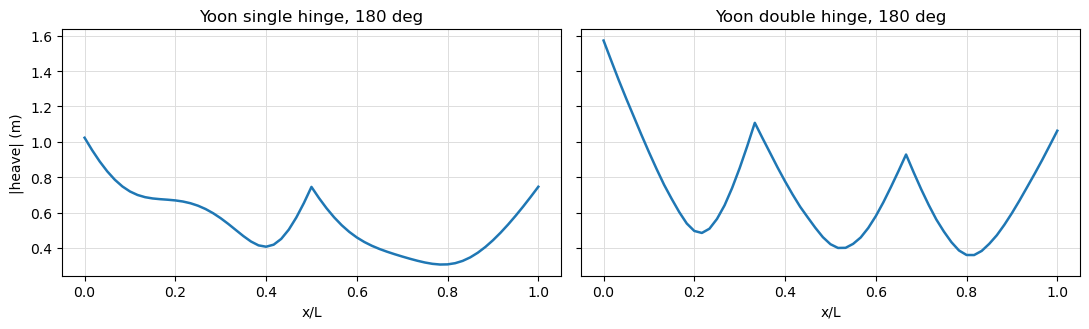

In [4]:
# ===== 1.3 绘制单铰接与双铰接中心线位移验证图 =====
# 这张图用于快速确认单铰接、双铰接的 heave 响应形态是否合理。

# 创建一行两列图窗，左边单铰接，右边双铰接。
fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.4), sharey=True)

# 遍历两个验证算例并绘制中心线响应。
for ax, case_id in zip(axes, YOON_VALIDATION_CASE_IDS):
    # 取出当前算例对象。
    case = yoon_results[case_id]["case"]

    # 取出当前算例 heave 网格。
    heave_grid = yoon_results[case_id]["heave_grid"]

    # 选择中间行作为中心线，便于与论文图件对照。
    center_row = heave_grid.shape[0] // 2

    # 构造归一化横坐标 x/L。
    x = np.linspace(0.0, 1.0, heave_grid.shape[1])

    # 绘制中心线垂向位移幅值。
    ax.plot(x, heave_grid[center_row], color="#1f77b4", linewidth=1.8)

    # 设置图题，明确是单铰接还是双铰接。
    ax.set_title(case.title)

    # 设置横坐标标签。
    ax.set_xlabel("x/L")

    # 开启网格，方便观察峰值和曲线连续性。
    ax.grid(True, color="#dddddd", linewidth=0.7)

# 设置共用纵坐标标签。
axes[0].set_ylabel("|heave| (m)")

# 自动调整图窗布局。
fig.tight_layout()

# 定义输出图像路径。
yoon_plot_path = NOTEBOOK_RESULT_ROOT / "yoon_single_double_hinge_centerline.png"

# 保存图像，便于写报告或论文记录。
fig.savefig(yoon_plot_path, dpi=220)

# 打印保存路径。
print(f"saved: {yoon_plot_path}")

# 在 notebook 中显示图像。
plt.show()

## 2. 10×10 铰接模型水弹性计算

本节使用 10×10 模块化浮体铰接算例。默认读取已经通过验证的响应文件；如果设置 `FORCE_RECOMPUTE=True`，则从质量矩阵、刚度矩阵和水动力文件重新进行频域水弹性求解。

In [5]:
# ===== 2.1 构建并验证 10×10 铰接算例 =====
# 这一节检查 10×10 模型的模块数、主节点数、铰接线和节点配对。

# 构建 10×10 标准铰接水弹性算例。
case_10x10 = build_complex_hinge_10x10_case(DATA_ROOT)

# 检查 10×10 算例所需输入文件是否存在。
missing_10x10_inputs = missing_complex_hinge_input_paths(case_10x10)

# 分离 x 方向铰接线，便于检查数量和释放自由度。
x_hinges = [hinge for hinge in case_10x10.hinges if hinge.name.startswith("x ")]

# 分离 y 方向铰接线，便于检查数量和释放自由度。
y_hinges = [hinge for hinge in case_10x10.hinges if hinge.name.startswith("y ")]

# 汇总所有节点配对，用于检查连接件总数。
all_hinge_pairs = [pair for hinge in case_10x10.hinges for pair in hinge.node_pairs_one_based]

# 汇总所有参与铰接的节点编号，用于检查编号范围。
all_hinge_nodes = [node for pair in all_hinge_pairs for node in pair]

# 验证 10×10 模块数量。
assert case_10x10.grid.module_count == 100

# 验证每个模块为 7×7 结构网格。
assert case_10x10.grid.nodes_per_module_side == 7

# 验证结构节点总数为 100×49=4900。
assert case_10x10.grid.total_nodes == 4900

# 验证水动力主节点数量为 100。
assert len(case_10x10.master_nodes_one_based) == 100

# 验证 x 方向铰接线数量为 90。
assert len(x_hinges) == 90

# 验证 y 方向铰接线数量为 90。
assert len(y_hinges) == 90

# 验证铰接节点配对总数为 1260。
assert len(all_hinge_pairs) == 1260

# 验证铰接节点编号没有越界。
assert min(all_hinge_nodes) >= 1 and max(all_hinge_nodes) <= case_10x10.grid.total_nodes

# 验证 x 方向铰接释放第 5 个 6DOF 自由度，即 zero-based index 4。
assert {hinge.released_dofs_zero_based for hinge in x_hinges} == {(4,)}

# 验证 y 方向铰接释放第 4 个 6DOF 自由度，即 zero-based index 3。
assert {hinge.released_dofs_zero_based for hinge in y_hinges} == {(3,)}

# 打印 10×10 算例摘要。
print(f"case id: {case_10x10.case_id}")
print(f"modules: {case_10x10.grid.module_count}")
print(f"total structural nodes: {case_10x10.grid.total_nodes}")
print(f"master nodes: {len(case_10x10.master_nodes_one_based)}")
print(f"x hinge lines: {len(x_hinges)}")
print(f"y hinge lines: {len(y_hinges)}")
print(f"hinge node pairs: {len(all_hinge_pairs)}")
print(f"missing inputs: {[str(path) for path in missing_10x10_inputs]}")

case id: complex_hinge_10x10_wl180_dir0
modules: 100
total structural nodes: 4900
master nodes: 100
x hinge lines: 90
y hinge lines: 90
hinge node pairs: 1260
missing inputs: []


In [6]:
# ===== 2.2 读取或重新计算 10×10 水弹性位移响应 =====
# response 是 24500×1 的复数向量，对应 4900 个结构节点 × 5 个保留自由度。

# 已验证的 10×10 全局响应文件路径。
response_10x10_path = BASE_10X10_RESULT_ROOT / "response.npy"

# 已验证的 10×10 合并界面后 heave 网格路径。
heave_10x10_path = BASE_10X10_RESULT_ROOT / "heave_grid_merged.npy"

# 当强制重算或标准响应文件不存在时，调用求解器。
if FORCE_RECOMPUTE or not response_10x10_path.exists():
    # 如果原始输入文件缺失，则不能重新求解。
    if missing_10x10_inputs:
        raise FileNotFoundError(f"Missing 10x10 inputs: {missing_10x10_inputs}")

    # 调用标准 10×10 频域水弹性求解流程。
    solved_10x10 = solve_complex_hinge_case(case_10x10)

    # 提取完整结构响应向量。
    response_10x10 = solved_10x10.response

    # 提取合并重复界面后的 heave 网格。
    heave_grid_10x10 = solved_10x10.heave_grid_merged

    # 提取当前频率点角频率，单位 rad/s。
    omega_10x10 = solved_10x10.omega

    # 保存本 notebook 重新计算得到的响应。
    np.save(NOTEBOOK_RESULT_ROOT / "response_10x10.npy", response_10x10)

    # 保存本 notebook 重新计算得到的 heave 网格。
    np.save(NOTEBOOK_RESULT_ROOT / "heave_grid_10x10.npy", heave_grid_10x10)

    # 记录结果来源。
    response_source = "fresh solve"
else:
    # 读取已经通过标准脚本验证的全局响应。
    response_10x10 = np.load(response_10x10_path)

    # 如果 heave 网格已保存，则直接读取。
    if heave_10x10_path.exists():
        heave_grid_10x10 = np.load(heave_10x10_path)

    # 如果 heave 网格不存在，则从全局响应中重新提取。
    else:
        heave_grid_10x10 = extract_complex_hinge_heave_grid(case_10x10, response_10x10, merge_interfaces=True)

    # 已保存的响应文件不单独携带 omega。
    omega_10x10 = None

    # 记录结果来源。
    response_source = str(response_10x10_path)

# 计算期望的响应向量尺寸。
expected_10x10_response_shape = (case_10x10.grid.total_nodes * case_10x10.retained_dofs_per_node, 1)

# 计算期望的合并后 heave 网格尺寸：10×(7-1)+1 = 61。
expected_10x10_grid_shape = (
    case_10x10.grid.modules_per_side * (case_10x10.grid.nodes_per_module_side - 1) + 1,
    case_10x10.grid.modules_per_side * (case_10x10.grid.nodes_per_module_side - 1) + 1,
)

# 验证响应向量尺寸正确。
assert response_10x10.shape == expected_10x10_response_shape

# 验证 heave 网格尺寸正确。
assert heave_grid_10x10.shape == expected_10x10_grid_shape

# 打印 10×10 位移响应摘要。
print(f"response source: {response_source}")
print(f"response shape: {response_10x10.shape}")
print(f"heave grid shape: {heave_grid_10x10.shape}")
print(f"max |response|: {np.abs(response_10x10).max():.6g}")
print(f"max |heave|: {np.abs(heave_grid_10x10).max():.6g}")
print(f"mean |heave|: {np.abs(heave_grid_10x10).mean():.6g}")

response source: /Users/yongkang/Projects/RODM_20250310_local/results/complex_hinge_10x10/response.npy
response shape: (24500, 1)
heave grid shape: (61, 61)
max |response|: 7.81101
max |heave|: 1.54047
mean |heave|: 1.07022


saved: /Users/yongkang/Projects/RODM_20250310_local/results/notebook_hinge_10x10_20260501/displacement_10x10_heave_and_centerlines.png


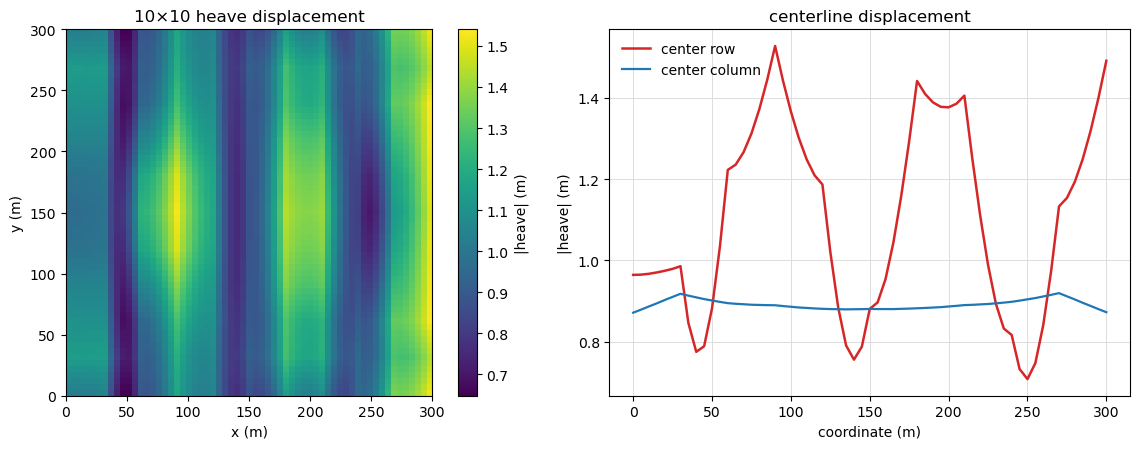

In [7]:
# ===== 2.3 绘制 10×10 位移云图与中心线响应 =====
# 左图是完整结构 heave 幅值云图；右图是中心行和中心列位移曲线。

# 创建一行两列图窗。
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))

# 设置物理坐标范围，单位为 m。
extent = [0.0, case_10x10.grid.structure_size, 0.0, case_10x10.grid.structure_size]

# 在左图绘制 heave 位移云图。
image = axes[0].imshow(heave_grid_10x10, origin="upper", extent=extent, cmap="viridis", aspect="equal")

# 设置左图标题。
axes[0].set_title("10×10 heave displacement")

# 设置左图 x 轴标签。
axes[0].set_xlabel("x (m)")

# 设置左图 y 轴标签。
axes[0].set_ylabel("y (m)")

# 添加颜色条，表示 heave 幅值。
fig.colorbar(image, ax=axes[0], label="|heave| (m)")

# 取 heave 网格中心行索引。
center_row = heave_grid_10x10.shape[0] // 2

# 取 heave 网格中心列索引。
center_col = heave_grid_10x10.shape[1] // 2

# 构造 x 方向物理坐标。
x_coord = np.linspace(0.0, case_10x10.grid.structure_size, heave_grid_10x10.shape[1])

# 构造 y 方向物理坐标。
y_coord = np.linspace(0.0, case_10x10.grid.structure_size, heave_grid_10x10.shape[0])

# 绘制中心行 heave 位移。
axes[1].plot(x_coord, heave_grid_10x10[center_row, :], color="#d62728", linewidth=1.8, label="center row")

# 绘制中心列 heave 位移。
axes[1].plot(y_coord, heave_grid_10x10[:, center_col], color="#1f77b4", linewidth=1.6, label="center column")

# 设置右图标题。
axes[1].set_title("centerline displacement")

# 设置右图横坐标标签。
axes[1].set_xlabel("coordinate (m)")

# 设置右图纵坐标标签。
axes[1].set_ylabel("|heave| (m)")

# 开启网格。
axes[1].grid(True, color="#dddddd", linewidth=0.7)

# 显示图例。
axes[1].legend(frameon=False)

# 自动调整布局。
fig.tight_layout()

# 定义位移图输出路径。
displacement_plot_path = NOTEBOOK_RESULT_ROOT / "displacement_10x10_heave_and_centerlines.png"

# 保存位移图。
fig.savefig(displacement_plot_path, dpi=220)

# 打印位移图输出路径。
print(f"saved: {displacement_plot_path}")

# 在 notebook 中显示位移图。
plt.show()

## 2.4 讨论一：优化连接刚度的必要性

本节回答第一个问题：对于 $300\ \mathrm{m}\times 300\ \mathrm{m}$ 模块化浮体，是否需要在全铰接基础上进一步优化连接刚度？

比较三类连接方案：

1. 全铰接方案：释放方向转动刚度为零。
2. 全刚接或高刚度方案：释放方向刚度取当前扫参中的最大值，用作刚接近似。
3. 均匀弹性方案：所有铰接线采用同一有限释放方向转动刚度。

这里先不引入空间分区优化，只复用已有单频 pitch 刚度扫参响应，比较位移收益与连接件内力代价。如果极端方案不能同时控制运动响应和连接件内力，则说明后续需要优化连接刚度，而不是简单采用全铰接或全刚接。

In [ ]:
# ===== 2.4.1 三类均匀连接方案的位移-内力-相对运动指标表 =====
# 本节只复用已有 pitch 刚度扫参响应，不重新求解 10×10 水弹性方程。

import json

from offshore_energy_sim.optimization import evaluate_design_response


def necessity_scheme_label(pitch_stiffness):
    # 将释放方向转动刚度映射到本节讨论的三类连接方案。
    if pitch_stiffness == 0.0:
        return "全铰接方案", "released stiffness = 0"
    if pitch_stiffness >= 1.0e10:
        return "高刚度近似刚接方案", "released stiffness = sweep maximum"
    return "均匀弹性方案", "all hinge lines share one finite released stiffness"


def necessity_component_indices(labels, requested_labels):
    # 根据连接件分量标签选择相对位移或相对转角分量。
    return tuple(index for index, label in enumerate(labels) if label in requested_labels)


def summarize_connector_relative_motion(case, response, omega, cid_prefix="necessity_delta"):
    # 使用同一套 Connector/G 框架恢复连接两侧的复相对运动 delta_hat。
    connectors = build_case_hinge_pair_connectors(case, cid_prefix=cid_prefix)
    recovered = recover_connector_response(
        np.asarray(response).reshape(-1),
        omega=float(omega),
        connectors=connectors,
    )

    # 初始化最大相对运动指标。
    metrics = {
        "max_relative_uz_envelope": 0.0,
        "max_relative_uz_cid": "",
        "max_relative_translation_envelope": 0.0,
        "max_relative_translation_cid": "",
        "max_relative_rotation_envelope": 0.0,
        "max_relative_rotation_cid": "",
        "max_released_relative_rotation_envelope": 0.0,
        "max_released_relative_rotation_cid": "",
    }

    # 遍历全部 1260 个连接件，计算谐波包络。
    for connector in connectors:
        delta_hat = np.asarray(recovered[connector.cid]["delta_hat"]).reshape(-1)
        labels = connector.labels
        uz_indices = necessity_component_indices(labels, ("uz",))
        translation_indices = necessity_component_indices(labels, ("ux", "uy", "uz"))
        rotation_indices = necessity_component_indices(labels, ("rx", "ry", "rz"))
        released_indices = tuple(connector.meta.get("released_retained_indices", ()))

        relative_uz, _ = harmonic_vector_norm_envelope(delta_hat[list(uz_indices)])
        relative_translation, _ = harmonic_vector_norm_envelope(delta_hat[list(translation_indices)])
        relative_rotation, _ = harmonic_vector_norm_envelope(delta_hat[list(rotation_indices)])
        released_rotation, _ = harmonic_vector_norm_envelope(delta_hat[list(released_indices)])

        if relative_uz > metrics["max_relative_uz_envelope"]:
            metrics["max_relative_uz_envelope"] = float(relative_uz)
            metrics["max_relative_uz_cid"] = connector.cid
        if relative_translation > metrics["max_relative_translation_envelope"]:
            metrics["max_relative_translation_envelope"] = float(relative_translation)
            metrics["max_relative_translation_cid"] = connector.cid
        if relative_rotation > metrics["max_relative_rotation_envelope"]:
            metrics["max_relative_rotation_envelope"] = float(relative_rotation)
            metrics["max_relative_rotation_cid"] = connector.cid
        if released_rotation > metrics["max_released_relative_rotation_envelope"]:
            metrics["max_released_relative_rotation_envelope"] = float(released_rotation)
            metrics["max_released_relative_rotation_cid"] = connector.cid

    return metrics


# 已有 pitch 刚度扫参结果目录。
necessity_sweep_root = REPO_ROOT / "results" / "complex_hinge_10x10_pitch_stiffness_sweep"

# centerline_records.json 记录每组刚度的响应文件、heave 网格和基本位移指标。
necessity_records_path = necessity_sweep_root / "centerline_records.json"

# 若该文件不存在，需要先运行 pitch 刚度扫参脚本。
if not necessity_records_path.exists():
    raise FileNotFoundError(f"Missing pitch stiffness sweep records: {necessity_records_path}")

# 读取已有扫参记录。
with necessity_records_path.open(encoding="utf-8") as file:
    necessity_records_data = json.load(file)

# 本节采用四个代表点：全铰接、两个有限均匀弹性刚度、高刚度近似刚接。
necessity_target_pitch_values = [0.0, 1.0e8, 1.0e9, 1.0e10]

# 建立刚度到记录的映射。
necessity_record_by_pitch = {
    float(record["pitch_stiffness"]): record
    for record in necessity_records_data["records"]
}

# 验证代表点完整。
missing_necessity_pitch_values = [
    value for value in necessity_target_pitch_values
    if value not in necessity_record_by_pitch
]
if missing_necessity_pitch_values:
    raise FileNotFoundError(f"Missing pitch records: {missing_necessity_pitch_values}")

# 汇总三类连接方案的关键指标。
optimization_necessity_rows = []

# 逐个代表方案恢复连接件包络指标。
for pitch_value in necessity_target_pitch_values:
    # 读取当前方案记录。
    record = necessity_record_by_pitch[pitch_value]

    # 加载该方案已有的全局响应和 heave 网格。
    response = np.load(Path(record["response_path"]))
    heave_grid = np.load(Path(record["grid_path"]))

    # 构建与该响应一致的 10×10 case，保证连接件 K 与响应设计一致。
    design_case = build_complex_hinge_10x10_case(
        DATA_ROOT,
        k_hinge=float(record["fixed_coupling_stiffness"]),
        released_dof_stiffness=float(record["pitch_stiffness"]),
    )

    # 使用核心优化评价接口计算 heave、连接件剪切力、弯矩和释放自由度弯矩。
    evaluation = evaluate_design_response(
        design_case,
        response,
        omega=float(record["omega"]),
        design={
            "pitch_stiffness": float(record["pitch_stiffness"]),
            "pitch_stiffness_label": record["pitch_stiffness_label"],
            "scheme_category": necessity_scheme_label(float(record["pitch_stiffness"]))[0],
        },
        scenario={
            "omega": float(record["omega"]),
            "frequency_index": case_10x10.frequency_index,
            "wave_direction_deg": 0.0,
            "scenario_label": "necessity_single_frequency",
        },
        heave_grid=heave_grid,
        cid_prefix="necessity",
    )

    # 额外恢复连接两侧相对运动，重点观察全铰接释放方向相对转角。
    relative_motion_metrics = summarize_connector_relative_motion(
        design_case,
        response,
        omega=float(record["omega"]),
        cid_prefix="necessity_delta",
    )

    # 组织本节讨论表的一行。
    scheme_category, scheme_note = necessity_scheme_label(float(record["pitch_stiffness"]))
    summary = evaluation.summary_row()
    center_row = np.asarray(record["center_row"], dtype=float)
    center_column = np.asarray(record["center_column"], dtype=float)
    optimization_necessity_rows.append(
        {
            "scheme_category": scheme_category,
            "scheme_note": scheme_note,
            "pitch_stiffness": float(record["pitch_stiffness"]),
            "pitch_stiffness_label": record["pitch_stiffness_label"],
            "omega": float(record["omega"]),
            "max_heave": float(summary["max_heave"]),
            "mean_heave": float(summary["mean_heave"]),
            "center_row_max_heave": float(center_row.max()),
            "center_column_max_heave": float(center_column.max()),
            "max_connector_shear_envelope": float(summary["max_connector_shear_envelope"]),
            "max_connector_shear_cid": summary["max_connector_shear_cid"],
            "max_connector_bending_envelope": float(summary["max_connector_bending_envelope"]),
            "max_connector_bending_cid": summary["max_connector_bending_cid"],
            "max_released_moment_envelope": float(summary["max_released_moment_envelope"]),
            "max_released_moment_cid": summary["max_released_moment_cid"],
            "max_relative_uz_envelope": relative_motion_metrics["max_relative_uz_envelope"],
            "max_relative_uz_cid": relative_motion_metrics["max_relative_uz_cid"],
            "max_relative_translation_envelope": relative_motion_metrics["max_relative_translation_envelope"],
            "max_relative_translation_cid": relative_motion_metrics["max_relative_translation_cid"],
            "max_relative_rotation_envelope": relative_motion_metrics["max_relative_rotation_envelope"],
            "max_relative_rotation_cid": relative_motion_metrics["max_relative_rotation_cid"],
            "max_released_relative_rotation_envelope": relative_motion_metrics["max_released_relative_rotation_envelope"],
            "max_released_relative_rotation_cid": relative_motion_metrics["max_released_relative_rotation_cid"],
        }
    )

# 以全铰接方案为基准，计算位移变化百分比和内力放大倍数。
full_hinge_row = next(row for row in optimization_necessity_rows if row["pitch_stiffness"] == 0.0)
for row in optimization_necessity_rows:
    row["max_heave_change_vs_full_hinge_pct"] = 100.0 * (
        row["max_heave"] / full_hinge_row["max_heave"] - 1.0
    )
    row["mean_heave_change_vs_full_hinge_pct"] = 100.0 * (
        row["mean_heave"] / full_hinge_row["mean_heave"] - 1.0
    )
    row["connector_shear_ratio_vs_full_hinge"] = (
        row["max_connector_shear_envelope"] / full_hinge_row["max_connector_shear_envelope"]
    )
    row["connector_bending_ratio_vs_full_hinge"] = (
        row["max_connector_bending_envelope"] / full_hinge_row["max_connector_bending_envelope"]
    )
    row["relative_uz_ratio_vs_full_hinge"] = (
        row["max_relative_uz_envelope"] / full_hinge_row["max_relative_uz_envelope"]
    )
    row["released_rotation_ratio_vs_full_hinge"] = (
        row["max_released_relative_rotation_envelope"] / full_hinge_row["max_released_relative_rotation_envelope"]
    )
    row["released_rotation_reduction_vs_full_hinge_pct"] = 100.0 * (
        1.0 - row["released_rotation_ratio_vs_full_hinge"]
    )

# 写出讨论一的 CSV 表格。
optimization_necessity_csv_path = NOTEBOOK_RESULT_ROOT / "optimization_necessity_uniform_scheme_summary.csv"
with optimization_necessity_csv_path.open("w", encoding="utf-8", newline="") as file:
    writer = csv.DictWriter(file, fieldnames=list(optimization_necessity_rows[0].keys()))
    writer.writeheader()
    writer.writerows(optimization_necessity_rows)

# 打印关键结果，作为 notebook 中的讨论表。
for row in optimization_necessity_rows:
    print(
        f"{row['scheme_category']} | k_pitch={row['pitch_stiffness_label']}: "
        f"max_heave={row['max_heave']:.4g}, mean_heave={row['mean_heave']:.4g}, "
        f"max_shear={row['max_connector_shear_envelope']:.4g}, "
        f"max_bending={row['max_connector_bending_envelope']:.4g}, "
        f"released_rotation={row['max_released_relative_rotation_envelope']:.4g} rad, "
        f"bending_ratio={row['connector_bending_ratio_vs_full_hinge']:.3g}"
    )

print(f"saved: {optimization_necessity_csv_path}")

In [ ]:
# ===== 2.4.2 绘制三类连接方案对比图并输出讨论结论 =====
# 图中同时显示位移收益和连接件内力代价，用于说明优化必要性。

# 为每个代表方案生成短标签；图中使用英文标签，避免无中文字体环境下保存图片缺字。
necessity_plot_name_by_pitch = {
    0.0: "released",
    1.0e8: "uniform elastic",
    1.0e9: "uniform elastic",
    1.0e10: "high stiffness",
}
necessity_labels = [
    f"{necessity_plot_name_by_pitch[row['pitch_stiffness']]}\nk={row['pitch_stiffness_label']}"
    for row in optimization_necessity_rows
]

# 横坐标为方案编号。
necessity_x = np.arange(len(optimization_necessity_rows))

# 提取位移和内力数组。
necessity_max_heave = np.asarray([row["max_heave"] for row in optimization_necessity_rows])
necessity_mean_heave = np.asarray([row["mean_heave"] for row in optimization_necessity_rows])
necessity_shear = np.asarray([row["max_connector_shear_envelope"] for row in optimization_necessity_rows])
necessity_bending = np.asarray([row["max_connector_bending_envelope"] for row in optimization_necessity_rows])

# 按方案类型指定颜色。
necessity_colors = []
for row in optimization_necessity_rows:
    if row["pitch_stiffness"] == 0.0:
        necessity_colors.append("#1b9e77")
    elif row["pitch_stiffness"] >= 1.0e10:
        necessity_colors.append("#d95f02")
    else:
        necessity_colors.append("#7570b3")

# 创建 2×2 图窗。
fig, axes = plt.subplots(2, 2, figsize=(12.0, 7.2))

# 最大与平均 heave 对比。
axes[0, 0].bar(necessity_x - 0.18, necessity_max_heave, width=0.36, color=necessity_colors, alpha=0.90, label="max")
axes[0, 0].bar(necessity_x + 0.18, necessity_mean_heave, width=0.36, color=necessity_colors, alpha=0.45, label="mean")
axes[0, 0].set_title("heave response")
axes[0, 0].set_ylabel("|heave| (m)")
axes[0, 0].grid(True, axis="y", color="#dddddd", linewidth=0.7)
axes[0, 0].legend(frameon=False)

# 最大连接件剪切力包络。
axes[0, 1].bar(necessity_x, necessity_shear, color=necessity_colors, alpha=0.85)
axes[0, 1].set_title("max connector shear envelope")
axes[0, 1].set_ylabel("envelope |Fz|")
axes[0, 1].grid(True, axis="y", color="#dddddd", linewidth=0.7)

# 最大连接件弯矩包络。
axes[1, 0].bar(necessity_x, necessity_bending, color=necessity_colors, alpha=0.85)
axes[1, 0].set_title("max connector bending envelope")
axes[1, 0].set_ylabel("envelope M")
axes[1, 0].grid(True, axis="y", color="#dddddd", linewidth=0.7)

# heave-bending 权衡散点图。
axes[1, 1].scatter(necessity_mean_heave, necessity_bending, s=86, c=necessity_colors)
for label, x_value, y_value in zip(necessity_labels, necessity_mean_heave, necessity_bending):
    y_offset = -22 if y_value > 0.85 * necessity_bending.max() else 5
    axes[1, 1].annotate(label, (x_value, y_value), textcoords="offset points", xytext=(5, y_offset), fontsize=8.0)
axes[1, 1].set_title("mean heave vs connector bending")
axes[1, 1].set_xlabel("mean heave (m)")
axes[1, 1].set_ylabel("max connector bending envelope")
axes[1, 1].set_xlim(necessity_mean_heave.min() - 0.02, necessity_mean_heave.max() + 0.04)
axes[1, 1].set_ylim(0.0, necessity_bending.max() * 1.14)
axes[1, 1].grid(True, color="#dddddd", linewidth=0.7)

# 设置分类横坐标标签。
for ax in (axes[0, 0], axes[0, 1], axes[1, 0]):
    ax.set_xticks(necessity_x)
    ax.set_xticklabels(necessity_labels, rotation=0, fontsize=8.0)

# 自动调整布局。
fig.tight_layout()

# 保存图像。
optimization_necessity_plot_path = NOTEBOOK_RESULT_ROOT / "optimization_necessity_uniform_scheme_comparison.png"
fig.savefig(optimization_necessity_plot_path, dpi=240)
print(f"saved: {optimization_necessity_plot_path}")
plt.show()

# 自动生成本节讨论结论。
best_mean_heave_row = min(optimization_necessity_rows, key=lambda row: row["mean_heave"])
lowest_bending_row = min(optimization_necessity_rows, key=lambda row: row["max_connector_bending_envelope"])
high_stiffness_row = next(row for row in optimization_necessity_rows if row["pitch_stiffness"] >= 1.0e10)

print("discussion conclusion:")
print(
    f"  全铰接方案的连接件弯矩最低，作为释放内力的基准；"
    f"但其 mean heave = {full_hinge_row['mean_heave']:.4g} m。"
)
print(
    f"  高刚度近似刚接方案的 mean heave = {high_stiffness_row['mean_heave']:.4g} m，"
    f"相对全铰接变化 {high_stiffness_row['mean_heave_change_vs_full_hinge_pct']:.2f}%，"
    f"但连接件弯矩放大到 {high_stiffness_row['connector_bending_ratio_vs_full_hinge']:.2f} 倍。"
)
print(
    f"  当前代表点中，mean heave 最小的是 {best_mean_heave_row['scheme_category']} "
    f"k={best_mean_heave_row['pitch_stiffness_label']}，"
    f"连接件弯矩最低的是 {lowest_bending_row['scheme_category']} "
    f"k={lowest_bending_row['pitch_stiffness_label']}。"
)
print("  因此，连接刚度不是越小或越大越好；运动响应和连接件内力之间存在权衡，需要进一步优化。")

### 2.4.3 连接处相对运动与相对转角

只看连接件弯矩会使全铰接方案显得最优，因为释放方向刚度为零时释放方向弯矩自然为零。为了判断全铰接是否真的足够好，还需要检查连接两侧的相对运动，尤其是释放方向相对转角。

本节用同一套 `Connector/G` 框架计算 `delta_hat = G @ x_hat`，并对 `uz` 相对位移和释放方向相对转角取谐波包络。如果全铰接的释放方向相对转角显著大于弹性连接方案，则说明弹性铰接的作用不是单纯增加刚度，而是在运动控制和连接内力之间寻找折中。

In [ ]:
# ===== 2.4.3 绘制连接处相对运动和释放方向相对转角 =====
# 这张图用于回答：全铰接的低弯矩是否以过大的相对转角为代价。

# 提取相对运动指标。
necessity_relative_uz = np.asarray([row["max_relative_uz_envelope"] for row in optimization_necessity_rows])
necessity_relative_translation = np.asarray([row["max_relative_translation_envelope"] for row in optimization_necessity_rows])
necessity_released_rotation = np.asarray([row["max_released_relative_rotation_envelope"] for row in optimization_necessity_rows])
necessity_rotation_reduction = np.asarray([row["released_rotation_reduction_vs_full_hinge_pct"] for row in optimization_necessity_rows])

# 创建相对运动图。
fig, axes = plt.subplots(2, 2, figsize=(12.0, 7.2))

# 最大释放方向相对转角。
axes[0, 0].bar(necessity_x, necessity_released_rotation, color=necessity_colors, alpha=0.88)
axes[0, 0].set_title("max released relative rotation")
axes[0, 0].set_ylabel("rotation envelope (rad)")
axes[0, 0].grid(True, axis="y", color="#dddddd", linewidth=0.7)

# 最大垂向相对位移。
axes[0, 1].bar(necessity_x, necessity_relative_uz, color=necessity_colors, alpha=0.88)
axes[0, 1].set_title("max relative heave across connectors")
axes[0, 1].set_ylabel("relative uz envelope (m)")
axes[0, 1].grid(True, axis="y", color="#dddddd", linewidth=0.7)

# 释放相对转角降低幅度。
axes[1, 0].bar(necessity_x, necessity_rotation_reduction, color=necessity_colors, alpha=0.88)
axes[1, 0].set_title("released rotation reduction vs released case")
axes[1, 0].set_ylabel("reduction (%)")
axes[1, 0].grid(True, axis="y", color="#dddddd", linewidth=0.7)

# 相对转角和连接件弯矩的权衡。
axes[1, 1].scatter(necessity_released_rotation, necessity_bending, s=86, c=necessity_colors)
for label, x_value, y_value in zip(necessity_labels, necessity_released_rotation, necessity_bending):
    y_offset = -22 if y_value > 0.85 * necessity_bending.max() else 5
    axes[1, 1].annotate(label, (x_value, y_value), textcoords="offset points", xytext=(5, y_offset), fontsize=8.0)
axes[1, 1].set_title("released rotation vs connector bending")
axes[1, 1].set_xlabel("max released relative rotation (rad)")
axes[1, 1].set_ylabel("max connector bending envelope")
axes[1, 1].grid(True, color="#dddddd", linewidth=0.7)

# 设置分类标签。
for ax in (axes[0, 0], axes[0, 1], axes[1, 0]):
    ax.set_xticks(necessity_x)
    ax.set_xticklabels(necessity_labels, rotation=0, fontsize=8.0)

# 自动调整布局。
fig.tight_layout()

# 保存相对运动图。
optimization_relative_motion_plot_path = NOTEBOOK_RESULT_ROOT / "optimization_necessity_relative_motion_comparison.png"
fig.savefig(optimization_relative_motion_plot_path, dpi=240)
print(f"saved: {optimization_relative_motion_plot_path}")
plt.show()

# 输出相对转角视角下的讨论结论。
min_released_rotation_row = min(optimization_necessity_rows, key=lambda row: row["max_released_relative_rotation_envelope"])
print("relative-motion conclusion:")
print(
    f"  全铰接方案释放方向最大相对转角 = {full_hinge_row['max_released_relative_rotation_envelope']:.4g} rad，"
    f"这是其低连接弯矩的代价。"
)
print(
    f"  高刚度近似刚接方案释放方向最大相对转角 = {high_stiffness_row['max_released_relative_rotation_envelope']:.4g} rad，"
    f"相对全铰接降低 {high_stiffness_row['released_rotation_reduction_vs_full_hinge_pct']:.2f}%，"
    f"但连接件弯矩放大到 {high_stiffness_row['connector_bending_ratio_vs_full_hinge']:.2f} 倍。"
)
print(
    f"  k_pitch=1e8 时相对转角降低 {optimization_necessity_rows[1]['released_rotation_reduction_vs_full_hinge_pct']:.2f}%，"
    f"弯矩放大 {optimization_necessity_rows[1]['connector_bending_ratio_vs_full_hinge']:.2f} 倍；"
    f"k_pitch=1e9 时相对转角降低 {optimization_necessity_rows[2]['released_rotation_reduction_vs_full_hinge_pct']:.2f}%，"
    f"弯矩放大 {optimization_necessity_rows[2]['connector_bending_ratio_vs_full_hinge']:.2f} 倍。"
)
print("  因此，全铰接不是没有代价；它把风险从连接件弯矩转移到了连接处相对转角。后续非均匀优化应围绕相对转角约束和连接件内力约束寻找折中。")

## 3. 斜入射与 Pitch 刚度中轴线响应

本节补充两个内容：

1. 汇总当前本地水动力数据中的入射角，重点检查是否存在 10×10 的 45° 斜入射数据。
2. 读取已有 pitch 铰接刚度扫参结果，将 `0 / 1e8 / 1e9 / 1e10` 四组中轴线 heave 响应绘制在同一张图中。

In [8]:
# ===== 3.1 汇总斜入射水动力数据 =====
# 这一节只检查本地数据文件，不进行水弹性求解。
# 目标是确认当前是否已经具备 10×10 的 45° 斜入射水动力数据。

# json 用于读取或写出结构化摘要。
import json

# re 用于从文件名中解析 direction0、direction45 等入射角信息。
import re

# hydrodynamic_root 指向外部数据中的水动力文件目录。
hydrodynamic_root = DATA_ROOT / "HydrodynamicData"

# 扫描所有 NetCDF 水动力文件；当前项目水动力数据主要保存为 .nc。
hydrodynamic_files = sorted(hydrodynamic_root.rglob("*.nc")) if hydrodynamic_root.exists() else []

# 用正则表达式从文件名中提取入射方向角度。
direction_pattern = re.compile(r"direction[_-]?(\d+)|dir[_-]?(\d+)", re.IGNORECASE)

# 创建水动力文件摘要列表，每个文件一行。
hydro_direction_rows = []

# 遍历本地水动力文件。
for file_path in hydrodynamic_files:
    # 从文件名中匹配 direction 后面的数字。
    match = direction_pattern.search(file_path.name)

    # 如果匹配成功，则提取第一个非空分组作为方向角。
    direction = int(next(group for group in match.groups() if group is not None)) if match else None

    # 根据文件名粗略判断数据属于 10×10、DM10 还是 DM6 算例。
    if "DM10_10" in file_path.name:
        model_family = "10x10"
    elif file_path.name.startswith("DM10_"):
        model_family = "Yoon_DM10"
    elif file_path.name.startswith("DM6_"):
        model_family = "Yoon_DM6"
    else:
        model_family = "unknown"

    # 保存当前水动力文件摘要。
    hydro_direction_rows.append(
        {
            "model_family": model_family,
            "direction_deg": direction,
            "file_name": file_path.name,
            "path": str(file_path),
        }
    )

# 按模型类别和方向角排序，便于阅读。
hydro_direction_rows = sorted(
    hydro_direction_rows,
    key=lambda row: (row["model_family"], -1 if row["direction_deg"] is None else row["direction_deg"], row["file_name"]),
)

# 定义水动力方向摘要 CSV 输出路径。
hydro_summary_csv_path = NOTEBOOK_RESULT_ROOT / "hydrodynamic_direction_inventory.csv"

# 将方向摘要写出到 CSV，方便后续追踪缺失数据。
with hydro_summary_csv_path.open("w", encoding="utf-8", newline="") as file:
    writer = csv.DictWriter(file, fieldnames=["model_family", "direction_deg", "file_name", "path"])
    writer.writeheader()
    writer.writerows(hydro_direction_rows)

# 汇总每个模型族已有的方向角。
directions_by_family = {}
for row in hydro_direction_rows:
    directions_by_family.setdefault(row["model_family"], set()).add(row["direction_deg"])

# 查找 10×10 的 45° 水动力文件。
ten_by_ten_45_files = [
    row for row in hydro_direction_rows
    if row["model_family"] == "10x10" and row["direction_deg"] == 45
]

# 查找所有 45° 水动力文件，不限模型族。
any_45_hydro_files = [row for row in hydro_direction_rows if row["direction_deg"] == 45]

# 历史参考图中包含 45 的文件，说明过去可能做过 45° 图件或后处理。
reference_45_figures = sorted((REPO_ROOT / "references" / "hinge_published" / "figures").glob("*45*"))

# 打印水动力方向摘要。
print("hydrodynamic direction inventory:")
for family, directions in sorted(directions_by_family.items()):
    clean_directions = sorted(direction for direction in directions if direction is not None)
    print(f"  {family}: {clean_directions}")

# 打印 10×10 的 45° 检查结果。
print()
print(f"10x10 direction 45 hydro files: {len(ten_by_ten_45_files)}")
for row in ten_by_ten_45_files:
    print(f"  {row['path']}")

# 打印任意模型族的 45° 检查结果。
print(f"all direction 45 hydro files: {len(any_45_hydro_files)}")
for row in any_45_hydro_files:
    print(f"  {row['model_family']}: {row['path']}")

# 打印历史 45° 图件，帮助追踪你记忆中的 45° case 来源。
print(f"reference figures containing 45: {len(reference_45_figures)}")
for figure_path in reference_45_figures:
    print(f"  {figure_path}")

# 给出当前可执行结论。
if not ten_by_ten_45_files:
    print()
    print("Conclusion: current local data has no 10x10 direction-45 NetCDF hydrodynamic file.")
    print("The repository does contain historical 45-degree reference figures, so the 45-degree case may be archived as figures rather than raw hydrodynamic data.")

# 打印 CSV 输出位置。
print(f"saved: {hydro_summary_csv_path}")

hydrodynamic direction inventory:
  10x10: [0]
  Yoon_DM10: [0, 180, 210, 240, 270]
  Yoon_DM6: [0, 30, 60, 90, 180]

10x10 direction 45 hydro files: 0
all direction 45 hydro files: 0
reference figures containing 45: 5
  /Users/yongkang/Projects/RODM_20250310_local/references/hinge_published/figures/3d_surface_45_1e0.pdf
  /Users/yongkang/Projects/RODM_20250310_local/references/hinge_published/figures/3d_surface_45_1e10.pdf
  /Users/yongkang/Projects/RODM_20250310_local/references/hinge_published/figures/3d_surface_45_1e8.pdf
  /Users/yongkang/Projects/RODM_20250310_local/references/hinge_published/figures/3d_surface_45_1e9.pdf
  /Users/yongkang/Projects/RODM_20250310_local/references/hinge_published/figures/heave_45_middle.pdf

Conclusion: current local data has no 10x10 direction-45 NetCDF hydrodynamic file.
The repository does contain historical 45-degree reference figures, so the 45-degree case may be archived as figures rather than raw hydrodynamic data.
saved: /Users/yongkang/Pro

{'pitch_stiffness': 0.0, 'pitch_stiffness_label': '0', 'grid_max_heave': 1.5404728758796746, 'grid_mean_heave': 1.0702196794471885, 'center_row_max_heave': 1.5276058366345413, 'center_column_max_heave': 0.9194242406472696, 'center_row_index': 30, 'center_column_index': 30, 'x_start_m': 0.0, 'x_end_m': 300.0}
{'pitch_stiffness': 100000000.0, 'pitch_stiffness_label': '1e8', 'grid_max_heave': 1.6673888113689677, 'grid_mean_heave': 0.9816604933772218, 'center_row_max_heave': 1.6200206236946977, 'center_column_max_heave': 0.7919106599075082, 'center_row_index': 30, 'center_column_index': 30, 'x_start_m': 0.0, 'x_end_m': 300.0}
{'pitch_stiffness': 1000000000.0, 'pitch_stiffness_label': '1e9', 'grid_max_heave': 1.6265949338335128, 'grid_mean_heave': 0.858367678463899, 'center_row_max_heave': 1.4878809394942323, 'center_column_max_heave': 0.6534703678938752, 'center_row_index': 30, 'center_column_index': 30, 'x_start_m': 0.0, 'x_end_m': 300.0}
{'pitch_stiffness': 10000000000.0, 'pitch_stiffnes

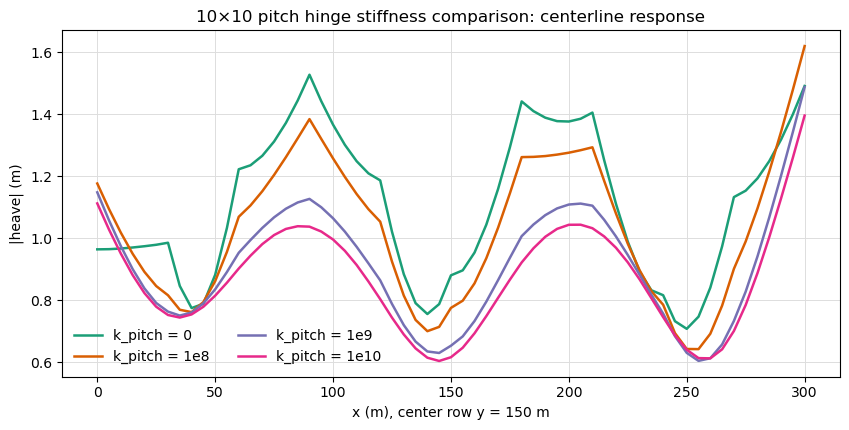

In [9]:
# ===== 3.2 绘制 Pitch 铰接刚度中轴线响应对比 =====
# 这里复用已有扫参结果，不重复求解 10×10 模型。
# pitch 刚度对应铰接矩阵中释放转动自由度的惩罚刚度。

# pitch_sweep_root 是已有 pitch 刚度扫参结果目录。
pitch_sweep_root = REPO_ROOT / "results" / "complex_hinge_10x10_pitch_stiffness_sweep"

# centerline_records.json 保存了每个 pitch 刚度下的中心行和中心列响应。
pitch_records_path = pitch_sweep_root / "centerline_records.json"

# 如果记录文件不存在，则说明需要先运行 scripts/compare_complex_hinge_10x10_stiffness.py。
if not pitch_records_path.exists():
    raise FileNotFoundError(f"Missing pitch stiffness sweep records: {pitch_records_path}")

# 读取已有 pitch 刚度扫参记录。
with pitch_records_path.open(encoding="utf-8") as file:
    pitch_records_data = json.load(file)

# 取出 records 列表。
pitch_records = pitch_records_data["records"]

# 只保留今天需要对比的四组 pitch 刚度。
target_pitch_stiffnesses = [0.0, 1.0e8, 1.0e9, 1.0e10]

# 建立刚度到记录的映射，方便按指定顺序绘图。
pitch_record_by_value = {float(record["pitch_stiffness"]): record for record in pitch_records}

# 验证四组刚度结果均存在。
missing_pitch_values = [value for value in target_pitch_stiffnesses if value not in pitch_record_by_value]
if missing_pitch_values:
    raise FileNotFoundError(f"Missing pitch stiffness records for: {missing_pitch_values}")

# 按 0、1e8、1e9、1e10 的顺序组织绘图记录。
ordered_pitch_records = [pitch_record_by_value[value] for value in target_pitch_stiffnesses]

# 创建摘要行，记录每组刚度的最大响应和中轴线最大响应。
pitch_summary_rows = []

# 遍历四组 pitch 刚度记录。
for record in ordered_pitch_records:
    # 读取中轴线 x 坐标，单位 m。
    x_coordinates = np.asarray(record["x_coordinates"], dtype=float)

    # 读取中心行 heave 响应。
    center_row = np.asarray(record["center_row"], dtype=float)

    # 读取中心列 heave 响应，作为辅助检查。
    center_column = np.asarray(record["center_column"], dtype=float)

    # 写入当前刚度的统计摘要。
    pitch_summary_rows.append(
        {
            "pitch_stiffness": float(record["pitch_stiffness"]),
            "pitch_stiffness_label": record["pitch_stiffness_label"],
            "grid_max_heave": float(record["grid_max"]),
            "grid_mean_heave": float(record["grid_mean"]),
            "center_row_max_heave": float(center_row.max()),
            "center_column_max_heave": float(center_column.max()),
            "center_row_index": int(record["center_row_index"]),
            "center_column_index": int(record["center_column_index"]),
            "x_start_m": float(x_coordinates[0]),
            "x_end_m": float(x_coordinates[-1]),
        }
    )

# 定义 pitch 刚度摘要 CSV 输出路径。
pitch_summary_csv_path = NOTEBOOK_RESULT_ROOT / "pitch_stiffness_centerline_summary.csv"

# 写出 pitch 刚度响应摘要。
with pitch_summary_csv_path.open("w", encoding="utf-8", newline="") as file:
    writer = csv.DictWriter(file, fieldnames=list(pitch_summary_rows[0].keys()))
    writer.writeheader()
    writer.writerows(pitch_summary_rows)

# 创建单张图，用于对比四组 pitch 刚度的中轴线响应。
fig, ax = plt.subplots(figsize=(8.6, 4.4))

# 为四条曲线指定颜色，保证图例清晰。
colors = ["#1b9e77", "#d95f02", "#7570b3", "#e7298a"]

# 遍历四组刚度并绘制中心行响应。
for color, record in zip(colors, ordered_pitch_records):
    # 读取 x 坐标。
    x_coordinates = np.asarray(record["x_coordinates"], dtype=float)

    # 读取中轴线响应。
    center_row = np.asarray(record["center_row"], dtype=float)

    # 生成图例标签。
    label = f"k_pitch = {record['pitch_stiffness_label']}"

    # 绘制当前刚度下的中轴线 heave 响应。
    ax.plot(x_coordinates, center_row, color=color, linewidth=1.8, label=label)

# 设置图标题。
ax.set_title("10×10 pitch hinge stiffness comparison: centerline response")

# 设置横坐标标签。
ax.set_xlabel("x (m), center row y = 150 m")

# 设置纵坐标标签。
ax.set_ylabel("|heave| (m)")

# 开启网格。
ax.grid(True, color="#dddddd", linewidth=0.7)

# 设置图例。
ax.legend(frameon=False, ncol=2)

# 自动调整图窗布局。
fig.tight_layout()

# 定义 pitch 中轴线对比图输出路径。
pitch_centerline_plot_path = NOTEBOOK_RESULT_ROOT / "pitch_stiffness_centerline_response_comparison.png"

# 保存图像。
fig.savefig(pitch_centerline_plot_path, dpi=240)

# 打印摘要。
for row in pitch_summary_rows:
    print(row)

# 打印输出路径。
print(f"saved: {pitch_summary_csv_path}")
print(f"saved: {pitch_centerline_plot_path}")

# 显示图像。
plt.show()

## 3.3 固定单频率下的 Pitch 刚度-性能权衡

本节不做频率扫描，也不重新求解水动力。直接复用已有 `k_pitch = 0 / 1e8 / 1e9 / 1e10` 的 10×10 响应结果，在同一个固定频率 `omega = 0.5851 rad/s` 下恢复连接件内力包络。

目标是回答一个更具体的问题：当 pitch 铰接刚度变化时，位移是否降低，连接件剪切力和弯矩是否增加，风险是否从运动响应转移到了连接件内力。

In [10]:
# ===== 3.3 固定 omega 下的 pitch 刚度-位移-连接件内力权衡 =====
# 这一节复用已有 pitch 扫参响应，不进行多频率水动力计算。

# 固定单频率 pitch 扫参结果目录。
pitch_sweep_root = REPO_ROOT / "results" / "complex_hinge_10x10_pitch_stiffness_sweep"

# 已保存的 pitch 扫参中心线和响应记录。
pitch_records_path = pitch_sweep_root / "centerline_records.json"

# 如果记录缺失，则需要先运行已有的 pitch 扫参脚本。
if not pitch_records_path.exists():
    raise FileNotFoundError(f"Missing pitch sweep records: {pitch_records_path}")

# 读取已有 pitch 扫参记录。
with pitch_records_path.open(encoding="utf-8") as file:
    pitch_records_data = json.load(file)

# 只分析当前已有且已验证的四组 pitch 刚度。
target_pitch_values = [0.0, 1.0e8, 1.0e9, 1.0e10]

# 建立 pitch 刚度到记录的映射。
pitch_record_by_value = {
    float(record["pitch_stiffness"]): record
    for record in pitch_records_data["records"]
}

# 检查四组记录是否完整。
missing_pitch_values = [value for value in target_pitch_values if value not in pitch_record_by_value]
if missing_pitch_values:
    raise FileNotFoundError(f"Missing pitch records: {missing_pitch_values}")


def component_indices(labels, requested_labels):
    # 根据连接件 labels 选择剪切力或弯矩分量；不存在的分量自动忽略。
    return tuple(index for index, label in enumerate(labels) if label in requested_labels)


def summarize_connector_envelopes_for_design(case, response, omega):
    # 将当前设计的全部铰接节点对转换为 Connector/G 对象。
    connectors = build_case_hinge_pair_connectors(case, cid_prefix="pitch_design")

    # 使用统一 Connector/G 框架恢复 delta_hat 和 force_hat。
    recovered = recover_connector_response(response.reshape(-1), omega=omega, connectors=connectors)

    # 为当前设计收集每个连接件的包络指标。
    rows = []
    for connector in connectors:
        # 取出当前连接件恢复结果。
        item = recovered[connector.cid]

        # 取出复连接件内力。
        force_hat = item["force_hat"]

        # 剪切力取 uz 分量。
        shear_indices = component_indices(connector.labels, ("uz",))

        # 弯矩取保留转动自由度 rx, ry；rz 在当前 5DOF 模型中已删除。
        bending_indices = component_indices(connector.labels, ("rx", "ry", "rz"))

        # 释放自由度弯矩用于区分理想铰接和弹性铰接。
        released_indices = tuple(connector.meta.get("released_retained_indices", ()))

        # 剪切力谐波包络。
        shear_envelope, shear_angle = harmonic_vector_norm_envelope(force_hat[list(shear_indices)])

        # 弯矩谐波包络。
        bending_envelope, bending_angle = harmonic_vector_norm_envelope(force_hat[list(bending_indices)])

        # 释放自由度弯矩谐波包络。
        released_envelope, released_angle = harmonic_vector_norm_envelope(force_hat[list(released_indices)])

        # 写入当前连接件指标。
        rows.append(
            {
                "cid": connector.cid,
                "hinge_line": connector.meta["hinge_line"],
                "hinge_name": connector.meta["hinge_name"],
                "pair_index": connector.meta["pair_index"],
                "node_a": connector.meta["node_a"],
                "node_b": connector.meta["node_b"],
                "shear_force_envelope": float(shear_envelope),
                "shear_force_angle_rad": float(shear_angle),
                "bending_moment_envelope": float(bending_envelope),
                "bending_moment_angle_rad": float(bending_angle),
                "released_moment_envelope": float(released_envelope),
                "released_moment_angle_rad": float(released_angle),
                "force_hat_max_component_abs": float(np.abs(force_hat).max()),
            }
        )

    # 返回当前设计的逐连接件结果。
    return rows


# 权衡分析输出目录。
tradeoff_root = NOTEBOOK_RESULT_ROOT / "pitch_single_frequency_tradeoff"
tradeoff_root.mkdir(parents=True, exist_ok=True)

# 汇总每组 pitch 刚度的最大位移、最大剪切力和最大弯矩。
tradeoff_rows = []

# 遍历四组 pitch 刚度。
for pitch_value in target_pitch_values:
    # 读取当前 pitch 记录。
    record = pitch_record_by_value[pitch_value]

    # 读取当前 pitch 响应向量。
    response_path = Path(record["response_path"])
    response = np.load(response_path)

    # 读取当前 pitch 合并 heave 网格。
    grid_path = Path(record["grid_path"])
    heave_grid = np.load(grid_path)

    # 当前 pitch 对应的求解频率，单位 rad/s。
    omega = float(record["omega"])

    # 根据当前 pitch 刚度构建 10×10 case，保证 connector K 与响应设计一致。
    pitch_case = build_complex_hinge_10x10_case(
        DATA_ROOT,
        k_hinge=float(record["fixed_coupling_stiffness"]),
        released_dof_stiffness=pitch_value,
    )

    # 恢复当前 pitch 设计下的所有连接件内力包络。
    connector_design_rows = summarize_connector_envelopes_for_design(pitch_case, response, omega)

    # 输出当前 pitch 的逐连接件结果，便于后续定位控制连接件。
    detail_csv_path = tradeoff_root / f"connector_envelopes_k_pitch_{record['pitch_stiffness_label']}.csv"
    with detail_csv_path.open("w", encoding="utf-8", newline="") as file:
        writer = csv.DictWriter(file, fieldnames=list(connector_design_rows[0].keys()))
        writer.writeheader()
        writer.writerows(connector_design_rows)

    # 找出当前 pitch 下控制剪切力的连接件。
    max_shear_row = max(connector_design_rows, key=lambda row: row["shear_force_envelope"])

    # 找出当前 pitch 下控制弯矩的连接件。
    max_bending_row = max(connector_design_rows, key=lambda row: row["bending_moment_envelope"])

    # 找出当前 pitch 下释放自由度弯矩最大的连接件。
    max_released_row = max(connector_design_rows, key=lambda row: row["released_moment_envelope"])

    # 写入当前 pitch 设计的汇总结果。
    tradeoff_rows.append(
        {
            "pitch_stiffness": pitch_value,
            "pitch_stiffness_label": record["pitch_stiffness_label"],
            "omega": omega,
            "max_heave": float(np.max(heave_grid)),
            "mean_heave": float(np.mean(heave_grid)),
            "max_connector_shear_envelope": max_shear_row["shear_force_envelope"],
            "max_connector_shear_cid": max_shear_row["cid"],
            "max_connector_bending_envelope": max_bending_row["bending_moment_envelope"],
            "max_connector_bending_cid": max_bending_row["cid"],
            "max_released_moment_envelope": max_released_row["released_moment_envelope"],
            "max_released_moment_cid": max_released_row["cid"],
            "detail_csv": str(detail_csv_path),
        }
    )

# 输出总权衡表。
tradeoff_summary_path = tradeoff_root / "pitch_single_frequency_tradeoff_summary.csv"
with tradeoff_summary_path.open("w", encoding="utf-8", newline="") as file:
    writer = csv.DictWriter(file, fieldnames=list(tradeoff_rows[0].keys()))
    writer.writeheader()
    writer.writerows(tradeoff_rows)

# 打印汇总表，便于 notebook 中直接查看。
for row in tradeoff_rows:
    print(row)
print(f"saved: {tradeoff_summary_path}")

{'pitch_stiffness': 0.0, 'pitch_stiffness_label': '0', 'omega': 0.5851, 'max_heave': 1.5404728758796746, 'mean_heave': 1.0702196794471885, 'max_connector_shear_envelope': 587154.9770477063, 'max_connector_shear_cid': 'pitch_design_046_004', 'max_connector_bending_envelope': 1258167.8331679332, 'max_connector_bending_cid': 'pitch_design_068_006', 'max_released_moment_envelope': 0.0, 'max_released_moment_cid': 'pitch_design_001_001', 'detail_csv': '/Users/yongkang/Projects/RODM_20250310_local/results/notebook_hinge_10x10_20260501/pitch_single_frequency_tradeoff/connector_envelopes_k_pitch_0.csv'}
{'pitch_stiffness': 100000000.0, 'pitch_stiffness_label': '1e8', 'omega': 0.5851, 'max_heave': 1.6673888113689677, 'mean_heave': 0.9816604933772218, 'max_connector_shear_envelope': 604097.581790142, 'max_connector_shear_cid': 'pitch_design_046_004', 'max_connector_bending_envelope': 2806229.3861489715, 'max_connector_bending_cid': 'pitch_design_039_006', 'max_released_moment_envelope': 2804440.9

saved: /Users/yongkang/Projects/RODM_20250310_local/results/notebook_hinge_10x10_20260501/pitch_single_frequency_tradeoff/pitch_single_frequency_tradeoff.png


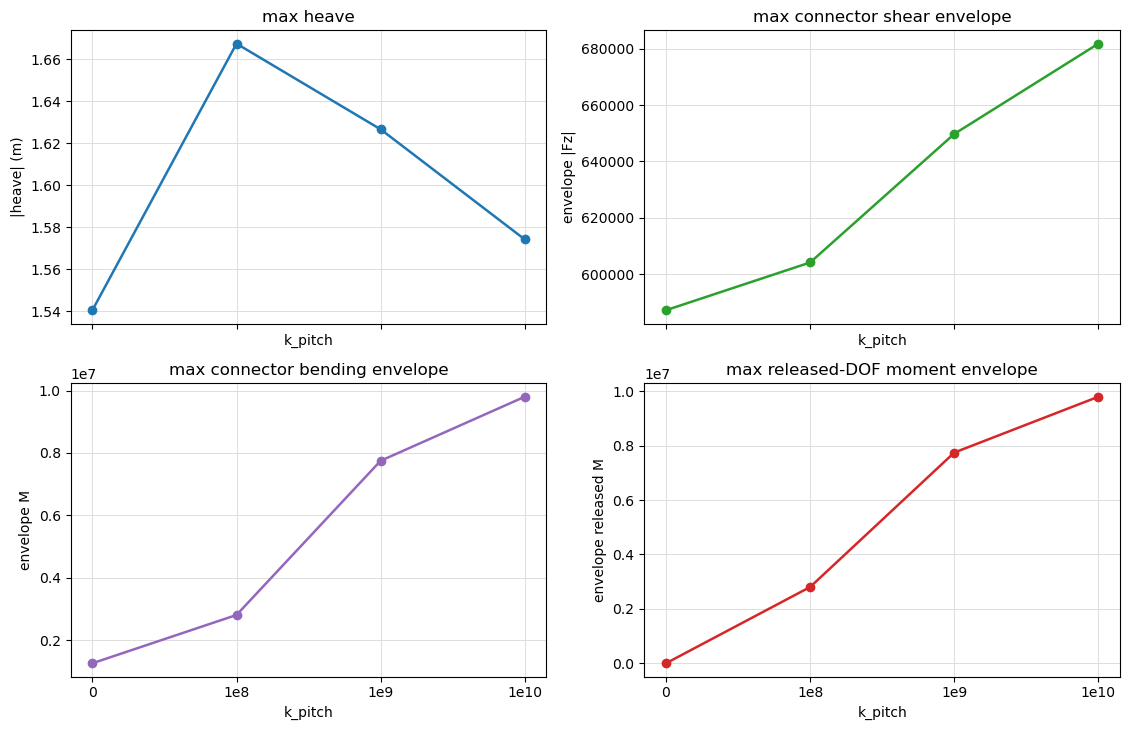

saved: /Users/yongkang/Projects/RODM_20250310_local/results/notebook_hinge_10x10_20260501/pitch_single_frequency_tradeoff/pitch_single_frequency_heave_force_tradeoff.png


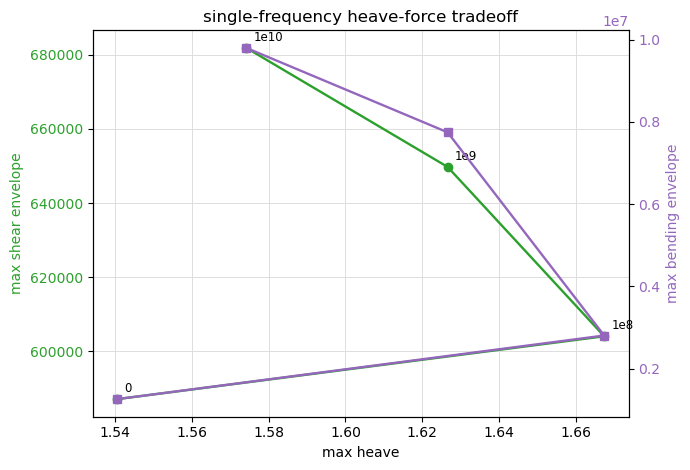

In [11]:
# ===== 3.4 绘制固定单频率 pitch 刚度权衡图 =====
# 横轴使用 pitch 刚度标签，避免 k=0 无法在对数轴上表达。

# pitch 刚度标签。
pitch_labels = [row["pitch_stiffness_label"] for row in tradeoff_rows]

# 横坐标为分类索引。
x_positions = np.arange(len(pitch_labels))

# 最大 heave。
max_heave_values = np.array([row["max_heave"] for row in tradeoff_rows])

# 最大连接件剪切力包络。
max_shear_values = np.array([row["max_connector_shear_envelope"] for row in tradeoff_rows])

# 最大连接件弯矩包络。
max_bending_values = np.array([row["max_connector_bending_envelope"] for row in tradeoff_rows])

# 最大释放自由度弯矩包络。
max_released_values = np.array([row["max_released_moment_envelope"] for row in tradeoff_rows])

# 创建 2×2 权衡图。
fig, axes = plt.subplots(2, 2, figsize=(11.4, 7.4), sharex=True)

# 位移响应。
axes[0, 0].plot(x_positions, max_heave_values, marker="o", color="#1f77b4", linewidth=1.8)
axes[0, 0].set_title("max heave")
axes[0, 0].set_ylabel("|heave| (m)")
axes[0, 0].grid(True, color="#dddddd", linewidth=0.7)

# 剪切力包络。
axes[0, 1].plot(x_positions, max_shear_values, marker="o", color="#2ca02c", linewidth=1.8)
axes[0, 1].set_title("max connector shear envelope")
axes[0, 1].set_ylabel("envelope |Fz|")
axes[0, 1].grid(True, color="#dddddd", linewidth=0.7)

# 弯矩包络。
axes[1, 0].plot(x_positions, max_bending_values, marker="o", color="#9467bd", linewidth=1.8)
axes[1, 0].set_title("max connector bending envelope")
axes[1, 0].set_ylabel("envelope M")
axes[1, 0].grid(True, color="#dddddd", linewidth=0.7)

# 释放自由度弯矩包络。
axes[1, 1].plot(x_positions, max_released_values, marker="o", color="#d62728", linewidth=1.8)
axes[1, 1].set_title("max released-DOF moment envelope")
axes[1, 1].set_ylabel("envelope released M")
axes[1, 1].grid(True, color="#dddddd", linewidth=0.7)

# 设置所有子图的横坐标标签。
for ax in axes.ravel():
    ax.set_xticks(x_positions)
    ax.set_xticklabels(pitch_labels)
    ax.set_xlabel("k_pitch")

# 自动调整布局。
fig.tight_layout()

# 输出权衡图路径。
tradeoff_plot_path = tradeoff_root / "pitch_single_frequency_tradeoff.png"
fig.savefig(tradeoff_plot_path, dpi=240)
print(f"saved: {tradeoff_plot_path}")
plt.show()

# 再画一张 heave-force tradeoff 图，更直观看风险转移。
fig, ax = plt.subplots(figsize=(7.0, 4.8))

# 用剪切力作为左轴。
ax.plot(max_heave_values, max_shear_values, marker="o", color="#2ca02c", linewidth=1.7, label="shear")
ax.set_xlabel("max heave")
ax.set_ylabel("max shear envelope", color="#2ca02c")
ax.tick_params(axis="y", labelcolor="#2ca02c")
ax.grid(True, color="#dddddd", linewidth=0.7)

# 右轴显示弯矩。
ax2 = ax.twinx()
ax2.plot(max_heave_values, max_bending_values, marker="s", color="#9467bd", linewidth=1.7, label="bending")
ax2.set_ylabel("max bending envelope", color="#9467bd")
ax2.tick_params(axis="y", labelcolor="#9467bd")

# 标注每个点的 pitch 刚度。
for label, x_value, y_value in zip(pitch_labels, max_heave_values, max_shear_values):
    ax.annotate(label, (x_value, y_value), textcoords="offset points", xytext=(5, 5), fontsize=8.5)

# 设置标题。
ax.set_title("single-frequency heave-force tradeoff")
fig.tight_layout()

# 输出 heave-force 权衡图路径。
heave_force_tradeoff_plot_path = tradeoff_root / "pitch_single_frequency_heave_force_tradeoff.png"
fig.savefig(heave_force_tradeoff_plot_path, dpi=240)
print(f"saved: {heave_force_tradeoff_plot_path}")
plt.show()

## 4. 连接件内力：剪切力与弯矩

连接件内力现在统一通过 `Connector/G` 框架恢复。对每个连接件：

`delta_hat = G @ x_hat`

`force_hat = (K + i omega C) @ delta_hat`

其中 `G` 是相对位移算子，`K` 是连接刚度，`C` 是可选连接阻尼。这样后续如果动力方程中也装配 `G.T @ (K + i omega C) @ G`，连接件内力恢复会和动力方程保持同一套连接关系。

优化目标不直接使用复内力实部，而使用谐波包络：

`max_phi ||real(force_hat * exp(i phi))||`

当前 10×10 响应为 5DOF，已删除绕 z 轴转动自由度，因此弯矩包络主要由保留的 `rx, ry` 分量计算。

In [12]:
# ===== 4.1 用统一 Connector/G 框架恢复连接件剪切力和弯矩 =====
# 每一对铰接节点转换成一个 Connector，共 1260 个连接件。

# 垂向剪切力使用 5DOF 响应中的 uz 分量。
SHEAR_LABELS = ("uz",)

# 弯矩使用保留转动自由度；当前 RODM 5DOF 中有 rx, ry，rz 已删除。
MOMENT_LABELS = ("rx", "ry", "rz")

# 如果响应是从已保存 .npy 读取的，omega_10x10 为空；当前连接件没有阻尼 C，因此该值不影响 force_hat。
connector_omega = 0.5851 if omega_10x10 is None else omega_10x10

# 从 case.hinges 生成逐节点对 Connector，每个 Connector 都包含自己的 G、K、labels 和 meta。
hinge_pair_connectors = build_case_hinge_pair_connectors(case_10x10, cid_prefix="10x10_hinge")

# 使用统一接口恢复每个连接件的复相对位移 delta_hat 和复内力 force_hat。
connector_recovered = recover_connector_response(
    response_10x10.reshape(-1),
    omega=connector_omega,
    connectors=hinge_pair_connectors,
)

# 旧的 case.hinges 直接恢复函数作为一致性对照，确保新旧结果没有数值偏差。
legacy_connector_force_results = compute_case_hinge_connector_forces(
    case_10x10,
    response_10x10,
    shear_full_dofs_zero_based=(2,),
    bending_moment_full_dofs_zero_based=(3, 4, 5),
)

# 计算新旧 force_hat 的最大差异；理论上应接近机器精度。
legacy_force_by_order = [result.generalized_force for result in legacy_connector_force_results]
new_force_by_order = [connector_recovered[connector.cid]["force_hat"] for connector in hinge_pair_connectors]
max_force_recovery_difference = max(
    float(np.linalg.norm(new_force - legacy_force))
    for new_force, legacy_force in zip(new_force_by_order, legacy_force_by_order)
)


def label_indices(labels, requested_labels):
    # 根据 labels 找到所需分量在 force_hat 中的索引；不存在的分量自动忽略。
    return tuple(index for index, label in enumerate(labels) if label in requested_labels)


def connector_summary_row(connector, recovered_item):
    # 取出当前连接件的复相对位移。
    delta_hat = recovered_item["delta_hat"]

    # 取出当前连接件的复内力。
    force_hat = recovered_item["force_hat"]

    # 取出当前连接件的分量标签，例如 ux, uy, uz, rx, ry。
    labels = connector.labels

    # 找到剪切力分量索引。
    shear_indices = label_indices(labels, SHEAR_LABELS)

    # 找到弯矩分量索引。
    moment_indices = label_indices(labels, MOMENT_LABELS)

    # 找到释放转动自由度在保留响应空间中的索引。
    released_indices = tuple(connector.meta.get("released_retained_indices", ()))

    # 计算剪切力谐波包络。
    shear_envelope, shear_angle = harmonic_vector_norm_envelope(force_hat[list(shear_indices)])

    # 计算弯矩谐波包络。
    bending_envelope, bending_angle = harmonic_vector_norm_envelope(force_hat[list(moment_indices)])

    # 计算释放转动自由度弯矩包络；理想铰接时应为 0，弹性铰接时可非零。
    released_envelope, released_angle = harmonic_vector_norm_envelope(force_hat[list(released_indices)])

    # 输出一行 CSV/绘图摘要。
    return {
        "cid": connector.cid,
        "hinge_line": connector.meta["hinge_line"],
        "hinge_name": connector.meta["hinge_name"],
        "pair_index": connector.meta["pair_index"],
        "node_a": connector.meta["node_a"],
        "node_b": connector.meta["node_b"],
        "shear_force_envelope": float(shear_envelope),
        "shear_force_angle_rad": float(shear_angle),
        "bending_moment_envelope": float(bending_envelope),
        "bending_moment_angle_rad": float(bending_angle),
        "released_moment_envelope": float(released_envelope),
        "released_moment_angle_rad": float(released_angle),
        "delta_hat_norm_abs": float(np.linalg.norm(np.abs(delta_hat))),
        "force_hat_max_component_abs": float(np.abs(force_hat).max()),
    }


# 生成所有连接件的摘要行。
connector_rows = [
    connector_summary_row(connector, connector_recovered[connector.cid])
    for connector in hinge_pair_connectors
]

# 定义连接件内力 CSV 输出路径。
connector_csv_path = NOTEBOOK_RESULT_ROOT / "connector_shear_bending_summary.csv"

# 将连接件剪切力、弯矩和释放自由度弯矩包络写入 CSV。
with connector_csv_path.open("w", encoding="utf-8", newline="") as file:
    writer = csv.DictWriter(file, fieldnames=list(connector_rows[0].keys()))
    writer.writeheader()
    writer.writerows(connector_rows)

# 找到剪切力最大的连接件节点对。
max_connector_shear = max(connector_rows, key=lambda row: row["shear_force_envelope"])

# 找到弯矩最大的连接件节点对。
max_connector_moment = max(connector_rows, key=lambda row: row["bending_moment_envelope"])

# 找到释放转动自由度弯矩最大的连接件节点对。
max_released_moment = max(connector_rows, key=lambda row: row["released_moment_envelope"])

# 打印连接件结果摘要。
print(f"connector pairs: {len(connector_rows)}")
print(f"connector omega used: {connector_omega}")
print(f"max new-vs-legacy force difference: {max_force_recovery_difference:.6e}")
print(f"saved: {connector_csv_path}")
print(f"max connector shear envelope: {max_connector_shear}")
print(f"max connector bending moment envelope: {max_connector_moment}")
print(f"max released hinge moment envelope: {max_released_moment}")

connector pairs: 1260
connector omega used: 0.5851
max new-vs-legacy force difference: 0.000000e+00
saved: /Users/yongkang/Projects/RODM_20250310_local/results/notebook_hinge_10x10_20260501/connector_shear_bending_summary.csv
max connector shear envelope: {'cid': '10x10_hinge_046_004', 'hinge_line': 46, 'hinge_name': 'x hinge line 46', 'pair_index': 4, 'node_a': 2478, 'node_b': 2521, 'shear_force_envelope': 587154.9828249178, 'shear_force_angle_rad': 2.948478587448187, 'bending_moment_envelope': 74880.07127216877, 'bending_moment_angle_rad': 0.8326935015999042, 'released_moment_envelope': 0.4708971872555252, 'released_moment_angle_rad': -3.052536140660393, 'delta_hat_norm_abs': 0.04708976879165147, 'force_hat_max_component_abs': 587154.9828249178}
max connector bending moment envelope: {'cid': '10x10_hinge_068_006', 'hinge_line': 68, 'hinge_name': 'x hinge line 68', 'pair_index': 6, 'node_a': 3668, 'node_b': 3711, 'shear_force_envelope': 248672.26699541777, 'shear_force_angle_rad': -2.

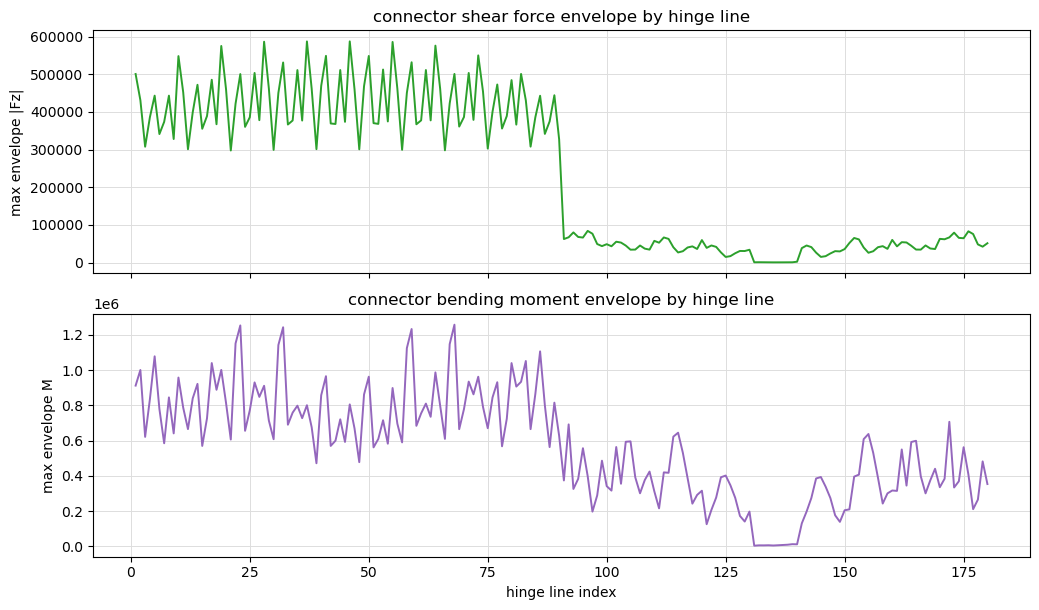

saved: /Users/yongkang/Projects/RODM_20250310_local/results/notebook_hinge_10x10_20260501/connector_shear_bending_by_hinge_line.png
saved: /Users/yongkang/Projects/RODM_20250310_local/results/notebook_hinge_10x10_20260501/connector_shear_bending_spatial_maps.png


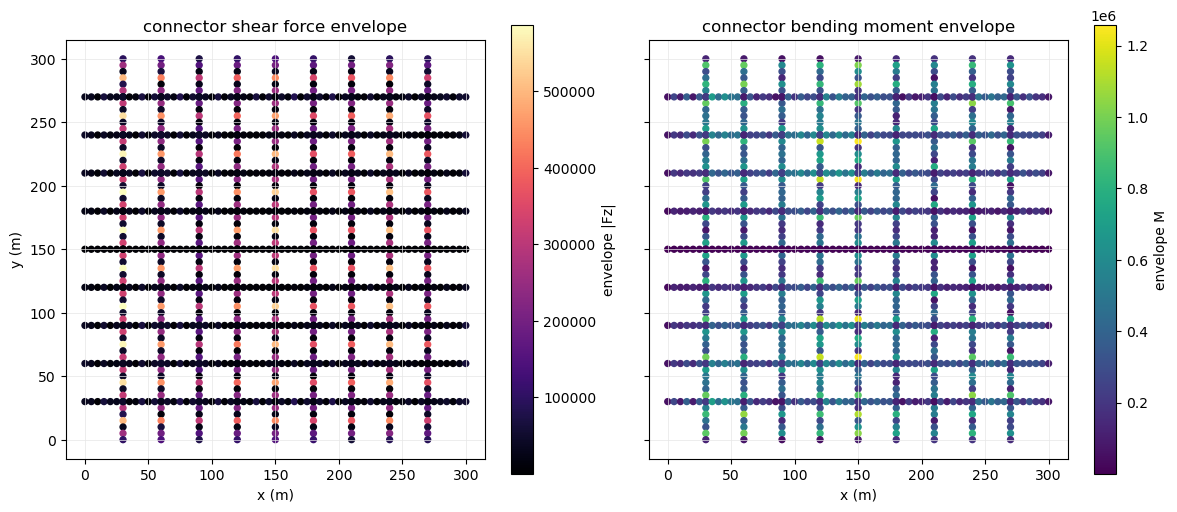

In [13]:
# ===== 4.2 绘制连接件剪切力与弯矩结果 =====
# 第一张图按铰接线编号统计最大值；第二张图按连接件空间位置绘制散点云图。

# 统计每条铰接线的最大剪切力包络。
connector_line_shear = {}

# 统计每条铰接线的最大弯矩包络。
connector_line_moment = {}

# 遍历连接件结果行。
for row in connector_rows:
    # 读取当前连接件所在铰接线编号。
    line = row["hinge_line"]

    # 更新该铰接线的最大剪切力包络。
    connector_line_shear[line] = max(
        connector_line_shear.get(line, 0.0),
        row["shear_force_envelope"],
    )

    # 更新该铰接线的最大弯矩包络。
    connector_line_moment[line] = max(
        connector_line_moment.get(line, 0.0),
        row["bending_moment_envelope"],
    )

# 按铰接线编号排序。
line_numbers = np.array(sorted(connector_line_shear))

# 得到每条铰接线的最大剪切力包络数组。
line_shear_values = np.array([connector_line_shear[line] for line in line_numbers])

# 得到每条铰接线的最大弯矩包络数组。
line_moment_values = np.array([connector_line_moment[line] for line in line_numbers])

# 创建上下两幅图，分别画剪切力和弯矩。
fig, axes = plt.subplots(2, 1, figsize=(10.5, 6.2), sharex=True)

# 绘制每条铰接线最大剪切力包络。
axes[0].plot(line_numbers, line_shear_values, color="#2ca02c", linewidth=1.4)
axes[0].set_title("connector shear force envelope by hinge line")
axes[0].set_ylabel("max envelope |Fz|")
axes[0].grid(True, color="#dddddd", linewidth=0.7)

# 绘制每条铰接线最大弯矩包络。
axes[1].plot(line_numbers, line_moment_values, color="#9467bd", linewidth=1.4)
axes[1].set_title("connector bending moment envelope by hinge line")
axes[1].set_xlabel("hinge line index")
axes[1].set_ylabel("max envelope M")
axes[1].grid(True, color="#dddddd", linewidth=0.7)

# 自动调整图窗布局。
fig.tight_layout()

# 定义连接件内力按铰接线输出路径。
connector_force_plot_path = NOTEBOOK_RESULT_ROOT / "connector_shear_bending_by_hinge_line.png"

# 保存连接件内力图。
fig.savefig(connector_force_plot_path, dpi=220)

# 在 notebook 中显示图像。
plt.show()


def node_xy_10x10(node_one_based, grid):
    # 将 10×10 模块化节点编号转换为结构平面坐标，用于连接件空间分布图。
    node_zero = node_one_based - 1
    module_index = node_zero // grid.nodes_per_module
    local_index = node_zero % grid.nodes_per_module
    module_row = module_index // grid.modules_per_side
    module_column = module_index % grid.modules_per_side
    local_row = local_index // grid.nodes_per_module_side
    local_column = local_index % grid.nodes_per_module_side
    spacing = grid.module_size / (grid.nodes_per_module_side - 1)
    x = module_column * grid.module_size + local_column * spacing
    y = grid.structure_size - (module_row * grid.module_size + local_row * spacing)
    return x, y


# 计算每个连接件节点对中点坐标。
mid_x = []
mid_y = []
for row in connector_rows:
    x_a, y_a = node_xy_10x10(row["node_a"], case_10x10.grid)
    x_b, y_b = node_xy_10x10(row["node_b"], case_10x10.grid)
    mid_x.append(0.5 * (x_a + x_b))
    mid_y.append(0.5 * (y_a + y_b))

# 转为数组便于绘图。
mid_x = np.asarray(mid_x)
mid_y = np.asarray(mid_y)
shear_values = np.asarray([row["shear_force_envelope"] for row in connector_rows])
moment_values = np.asarray([row["bending_moment_envelope"] for row in connector_rows])

# 创建空间分布图，左边剪切力，右边弯矩。
fig, axes = plt.subplots(1, 2, figsize=(12.0, 5.1), sharex=True, sharey=True)

# 绘制剪切力空间分布。
shear_scatter = axes[0].scatter(mid_x, mid_y, c=shear_values, s=18, cmap="magma")
axes[0].set_title("connector shear force envelope")
axes[0].set_xlabel("x (m)")
axes[0].set_ylabel("y (m)")
axes[0].set_aspect("equal")
axes[0].grid(True, color="#e6e6e6", linewidth=0.5)
fig.colorbar(shear_scatter, ax=axes[0], label="envelope |Fz|")

# 绘制弯矩空间分布。
moment_scatter = axes[1].scatter(mid_x, mid_y, c=moment_values, s=18, cmap="viridis")
axes[1].set_title("connector bending moment envelope")
axes[1].set_xlabel("x (m)")
axes[1].set_aspect("equal")
axes[1].grid(True, color="#e6e6e6", linewidth=0.5)
fig.colorbar(moment_scatter, ax=axes[1], label="envelope M")

# 自动调整布局。
fig.tight_layout()

# 定义连接件空间分布图输出路径。
connector_spatial_plot_path = NOTEBOOK_RESULT_ROOT / "connector_shear_bending_spatial_maps.png"

# 保存空间分布图。
fig.savefig(connector_spatial_plot_path, dpi=240)

# 打印输出路径。
print(f"saved: {connector_force_plot_path}")
print(f"saved: {connector_spatial_plot_path}")

# 在 notebook 中显示空间分布图。
plt.show()

## 5. 浮体模块内力：剪切力与弯矩

浮体模块等效内力采用单模块结构刚度矩阵与该模块位移相乘：

`f_module = K_module @ u_module`

这里先输出模块级统计结果：每个模块内部节点的最大垂向剪切力 `|Fz|`，以及最大弯矩合成值 `sqrt(Mx^2 + My^2)`。这一步是后续强度校核和优化目标函数的基础。

In [14]:
# ===== 5.1 计算每个浮体模块的等效剪切力和弯矩 =====
# 该计算使用单模块刚度矩阵，不改变 10×10 水弹性求解结果。
# 注意：这里的模块力已经处在 5DOF 保留响应空间，所以弯矩索引用 rx, ry = (3, 4)。

MODULE_SHEAR_DOF_INDEX = 2
MODULE_MOMENT_DOF_INDICES = (3, 4)


def read_reduced_module_stiffness(case):
    # 读取 Abaqus 输出的 6DOF 单模块刚度矩阵。
    stiffness_6dof = read_abaqus_matrix_sparse(case.stiffness_matrix_path)

    # 生成保留自由度索引，将 6DOF 裁剪成水弹性响应使用的 5DOF。
    keep = retained_dof_indices(
        case.grid.nodes_per_module,
        case.grid.dofs_per_node,
        case.removed_full_dofs_zero_based,
    )

    # 返回裁剪后的 5DOF 单模块刚度矩阵。
    return stiffness_6dof[keep][:, keep].tocsr()


def floating_body_force_rows(case, response, reduced_module_stiffness):
    # 把全局响应向量整理成 节点数 × 5DOF 的二维数组。
    nodal_response = response.reshape(case.grid.total_nodes, case.retained_dofs_per_node)

    # 创建结果行列表，每个模块写入一行。
    rows = []

    # 读取每边模块数量，用于把模块编号转换成二维网格位置。
    module_side = case.grid.modules_per_side

    # 读取单模块节点数，默认 7×7=49。
    nodes_per_module = case.grid.nodes_per_module

    # 遍历 100 个模块。
    for module_index in range(case.grid.module_count):
        # 计算当前模块在全局节点数组中的起始位置。
        start = module_index * nodes_per_module

        # 计算当前模块在全局节点数组中的终止位置。
        stop = start + nodes_per_module

        # 提取当前模块 49 个节点的 5DOF 位移。
        module_displacement = nodal_response[start:stop].reshape(nodes_per_module * case.retained_dofs_per_node, 1)

        # 通过单模块刚度矩阵乘位移得到模块等效节点力。
        module_force = reduced_module_stiffness @ module_displacement

        # 将模块力向量整理成 49×5DOF 形式。
        nodal_force = np.asarray(module_force).reshape(nodes_per_module, case.retained_dofs_per_node)

        # 垂向剪切力取所有节点 Fz 幅值的最大值。
        max_shear_force_abs = float(np.abs(nodal_force[:, MODULE_SHEAR_DOF_INDEX]).max())

        # 弯矩取每个节点 Mx, My 合成值，然后取最大值。
        bending_moment_per_node = np.linalg.norm(np.abs(nodal_force[:, list(MODULE_MOMENT_DOF_INDICES)]), axis=1)

        # 记录当前模块最大弯矩。
        max_bending_moment_abs = float(bending_moment_per_node.max())

        # 写入当前模块的统计结果。
        rows.append(
            {
                "module_number": module_index + 1,
                "module_row": module_index // module_side + 1,
                "module_column": module_index % module_side + 1,
                "max_shear_force_abs": max_shear_force_abs,
                "max_bending_moment_abs": max_bending_moment_abs,
                "max_component_abs": float(np.abs(nodal_force).max()),
            }
        )

    # 返回 100 个模块的内力统计。
    return rows


# 如果单模块刚度矩阵不存在，则明确报错。
if not case_10x10.stiffness_matrix_path.exists():
    raise FileNotFoundError(f"Missing module stiffness matrix: {case_10x10.stiffness_matrix_path}")

# 读取 5DOF 单模块刚度矩阵。
reduced_module_stiffness = read_reduced_module_stiffness(case_10x10)

# 计算 100 个模块的等效剪切力和弯矩。
floating_rows = floating_body_force_rows(case_10x10, response_10x10, reduced_module_stiffness)

# 定义浮体模块内力 CSV 输出路径。
floating_csv_path = NOTEBOOK_RESULT_ROOT / "floating_body_shear_bending_summary.csv"

# 将浮体模块内力结果写入 CSV。
with floating_csv_path.open("w", encoding="utf-8", newline="") as file:
    writer = csv.DictWriter(file, fieldnames=list(floating_rows[0].keys()))
    writer.writeheader()
    writer.writerows(floating_rows)

# 找到剪切力最大的模块。
max_module_shear = max(floating_rows, key=lambda row: row["max_shear_force_abs"])

# 找到弯矩最大的模块。
max_module_moment = max(floating_rows, key=lambda row: row["max_bending_moment_abs"])

# 打印模块内力摘要。
print(f"module stiffness shape: {reduced_module_stiffness.shape}")
print(f"floating modules: {len(floating_rows)}")
print(f"saved: {floating_csv_path}")
print(f"max module shear: {max_module_shear}")
print(f"max module bending moment: {max_module_moment}")

module stiffness shape: (245, 245)
floating modules: 100
saved: /Users/yongkang/Projects/RODM_20250310_local/results/notebook_hinge_10x10_20260501/floating_body_shear_bending_summary.csv
max module shear: {'module_number': 21, 'module_row': 3, 'module_column': 1, 'max_shear_force_abs': 1378238.632872387, 'max_bending_moment_abs': 20379372.120534446, 'max_component_abs': 20218239.43099142}
max module bending moment: {'module_number': 52, 'module_row': 6, 'module_column': 2, 'max_shear_force_abs': 1002410.1258015287, 'max_bending_moment_abs': 30709151.152994562, 'max_component_abs': 30686923.793270737}


saved: /Users/yongkang/Projects/RODM_20250310_local/results/notebook_hinge_10x10_20260501/module_shear_bending_heatmaps.png


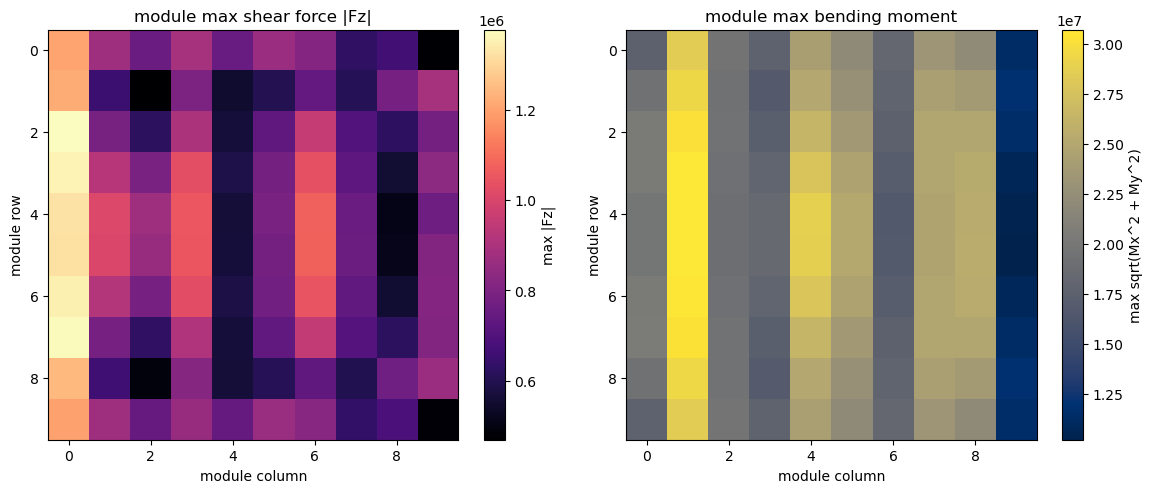

In [15]:
# ===== 5.2 绘制 10×10 浮体模块剪切力和弯矩热力图 =====
# 每个热力图单元对应一个 30 m × 30 m 模块。

# 将模块剪切力整理成 10×10 网格。
module_shear_grid = np.array([row["max_shear_force_abs"] for row in floating_rows]).reshape(
    case_10x10.grid.modules_per_side,
    case_10x10.grid.modules_per_side,
)

# 将模块弯矩整理成 10×10 网格。
module_moment_grid = np.array([row["max_bending_moment_abs"] for row in floating_rows]).reshape(
    case_10x10.grid.modules_per_side,
    case_10x10.grid.modules_per_side,
)

# 创建一行两列图窗，分别显示剪切力和弯矩。
fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.8))

# 绘制模块最大剪切力热力图。
image_shear = axes[0].imshow(module_shear_grid, origin="upper", cmap="magma", aspect="equal")

# 设置剪切力热力图标题。
axes[0].set_title("module max shear force |Fz|")

# 设置剪切力图横坐标。
axes[0].set_xlabel("module column")

# 设置剪切力图纵坐标。
axes[0].set_ylabel("module row")

# 添加剪切力颜色条。
fig.colorbar(image_shear, ax=axes[0], label="max |Fz|")

# 绘制模块最大弯矩热力图。
image_moment = axes[1].imshow(module_moment_grid, origin="upper", cmap="cividis", aspect="equal")

# 设置弯矩热力图标题。
axes[1].set_title("module max bending moment")

# 设置弯矩图横坐标。
axes[1].set_xlabel("module column")

# 设置弯矩图纵坐标。
axes[1].set_ylabel("module row")

# 添加弯矩颜色条。
fig.colorbar(image_moment, ax=axes[1], label="max sqrt(Mx^2 + My^2)")

# 自动调整布局。
fig.tight_layout()

# 定义模块内力热力图输出路径。
module_force_plot_path = NOTEBOOK_RESULT_ROOT / "module_shear_bending_heatmaps.png"

# 保存模块内力热力图。
fig.savefig(module_force_plot_path, dpi=220)

# 打印输出路径。
print(f"saved: {module_force_plot_path}")

# 在 notebook 中显示模块内力热力图。
plt.show()

## 6. 多目标优化问题占位

本节只定义优化问题，不执行优化。当前目标函数可以从上面的位移、连接件剪切力/弯矩、浮体剪切力/弯矩结果中直接读取，为后续参数扫描、`scipy.optimize` 或 NSGA-II 做准备。

In [16]:
# ===== 6.1 定义连接刚度多目标优化问题 =====
# 这里不引入复杂优化框架，只建立设计变量、目标和约束的统一描述。

# 定义 x/y 两组均匀铰接刚度设计变量。
design_variables = uniform_hinge_stiffness_variables(
    initial_k=case_10x10.hinges[0].k_hinge,
    lower_bound=1.0e6,
    upper_bound=1.0e12,
)

# 定义优化目标：最大位移、最大连接件剪切力、最大连接件弯矩、最大模块剪切力和最大模块弯矩。
objectives = (
    ConnectorObjectiveSpec(kind="max_heave", weight=1.0, description="Minimize maximum heave displacement magnitude."),
    ConnectorObjectiveSpec(kind="max_connector_force", weight=1.0, description="Minimize maximum connector shear force."),
    ConnectorObjectiveSpec(kind="custom", weight=1.0, description="Minimize maximum connector bending moment."),
    ConnectorObjectiveSpec(kind="custom", weight=1.0, description="Minimize maximum floating-body shear force."),
    ConnectorObjectiveSpec(kind="custom", weight=1.0, description="Minimize maximum floating-body bending moment."),
)

# 定义约束占位；具体容许值需要结合规范、试验或设计要求确定。
constraints = (
    "max_heave_abs <= allowable_heave",
    "max_connector_shear_abs <= allowable_connector_shear",
    "max_connector_bending_moment_abs <= allowable_connector_moment",
    "max_module_shear_abs <= allowable_module_shear",
    "max_module_bending_moment_abs <= allowable_module_moment",
)

# 组装优化问题描述对象。
optimization_problem = ConnectorOptimizationProblem(
    case_id=case_10x10.case_id,
    design_variables=design_variables,
    objectives=objectives,
    constraints=constraints,
)

# 汇总当前设计点的目标函数数值。
current_objective_values = {
    "max_heave_abs": float(np.abs(heave_grid_10x10).max()),
    "max_connector_shear_abs": float(max(row["shear_force_envelope"] for row in connector_rows)),
    "max_connector_bending_moment_abs": float(max(row["bending_moment_envelope"] for row in connector_rows)),
    "max_module_shear_abs": float(max(row["max_shear_force_abs"] for row in floating_rows)),
    "max_module_bending_moment_abs": float(max(row["max_bending_moment_abs"] for row in floating_rows)),
}

# 打印设计变量。
print("design variables:")
for variable in optimization_problem.design_variables:
    print(f"  {variable.name}: initial={variable.initial_value:.3e}, bounds=({variable.lower_bound:.3e}, {variable.upper_bound:.3e})")

# 打印优化目标。
print()
print("objectives:")
for objective in optimization_problem.objectives:
    print(f"  {objective.kind}: {objective.description}")

# 打印当前目标函数数值。
print()
print("current objective values:")
for key, value in current_objective_values.items():
    print(f"  {key}: {value:.6g}")

design variables:
  k_hinge_x: initial=1.000e+10, bounds=(1.000e+06, 1.000e+12)
  k_hinge_y: initial=1.000e+10, bounds=(1.000e+06, 1.000e+12)

objectives:
  max_heave: Minimize maximum heave displacement magnitude.
  max_connector_force: Minimize maximum connector shear force.
  custom: Minimize maximum connector bending moment.
  custom: Minimize maximum floating-body shear force.
  custom: Minimize maximum floating-body bending moment.

current objective values:
  max_heave_abs: 1.54047
  max_connector_shear_abs: 587155
  max_connector_bending_moment_abs: 1.25817e+06
  max_module_shear_abs: 1.37824e+06
  max_module_bending_moment_abs: 3.07092e+07


## 7. 当前 notebook 验收点

- 单铰接 `single_180` 和双铰接 `double_180` 完成拓扑与响应 sanity check。
- 10×10 铰接模型完成拓扑验证，并读取或计算全局水弹性位移响应。
- 位移结果已绘制 heave 云图和中心线曲线。
- 已新增优化必要性讨论：比较全铰接、均匀弹性和高刚度近似刚接三类方案，输出位移-连接件内力-相对运动权衡表和对比图。
- 已恢复连接两侧相对运动 `delta_hat`，并证明全铰接的低弯矩代价是更大的释放方向相对转角。
- 已汇总本地水动力入射角数据；当前未发现 10×10 的 45° NetCDF 水动力文件，但历史参考图中存在 45° 图件。
- 已将 pitch 铰接刚度 `0 / 1e8 / 1e9 / 1e10` 的中轴线响应绘制在同一张图中。
- 已在固定单频率 `omega = 0.5851 rad/s` 下完成 pitch 刚度-位移-连接件剪切力/弯矩权衡分析。
- 连接件内力已通过 `offshore_energy_sim.strength.compute_case_hinge_connector_forces` 输出剪切力、弯矩和释放转动自由度弯矩。
- 浮体模块等效内力已输出模块级剪切力和弯矩热力图。
- 多目标优化问题已完成设计变量、目标函数和约束占位。